In [1]:
import os
import pandas as pd

import os
import numpy as np 
import pandas as pd
#import cudf # to leverage GPU acceleration #cant be used on mac
#import polars as pl #use on mac to process big data faster
import time  # To measure execution time
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm

In [2]:
print(os.getcwd())    
print()
print(os.listdir(".."))

/Users/cagandeliktas/Master-thesis-Cagan/Preprocessing

['.DS_Store', 'Modelling', 'LLM Feature Extraction', '.gitignore', '.ipynb_checkpoints', 'Preprocessing', '.git', 'data', 'Outputs', '.idea']


## part 1

In [3]:
input_path_hosp = "../data/mimiciv/3.1/hosp/"
input_path_icu = "../data/mimiciv/3.1/icu/"

In [4]:
# Load the first few rows to understand the structure
diagnoses_df = pd.read_csv(f"{input_path_hosp}diagnoses_icd.csv.gz")
print(f"number of observations: {len(diagnoses_df)}")
print(f"number of unique hospital admissions: {diagnoses_df['hadm_id'].nunique()}")
print(f"number of unique patients: {diagnoses_df['subject_id'].nunique()}")

number of observations: 6364488
number of unique hospital admissions: 545497
number of unique patients: 223291


In [5]:
diagnoses_df.head()

,subject_id,hadm_id,seq_num,icd_code,icd_version
0,10000032,22595853,1,5723,9
1,10000032,22595853,2,78959,9
2,10000032,22595853,3,5715,9
3,10000032,22595853,4,07070,9
4,10000032,22595853,5,496,9


In [6]:
# Load and preview
patients_df = pd.read_csv(f"{input_path_hosp}patients.csv.gz")
print(f"number of observations: {len(patients_df)}")
print(f"number of unique patients: {patients_df['subject_id'].nunique()}")

number of observations: 364627
number of unique patients: 364627


In [7]:
patients_df.head()

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10000032,F,52,2180,2014 - 2016,2180-09-09
1,10000048,F,23,2126,2008 - 2010,NaN
2,10000058,F,33,2168,2020 - 2022,NaN
3,10000068,F,19,2160,2008 - 2010,NaN
4,10000084,M,72,2160,2017 - 2019,2161-02-13


In [8]:
# Load and preview
icu_df = pd.read_csv(f"{input_path_icu}icustays.csv.gz")
print(f"Total number of observations: {len(icu_df)}")
print(f"Total number of unique patients in ICU: {icu_df['stay_id'].nunique()}. PC: Should be equal to the total number of observations.")

Total number of observations: 94458
Total number of unique patients in ICU: 94458. PC: Should be equal to the total number of observations.


In [9]:
icu_df.head()

,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los
0,10000032,29079034,39553978,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2180-07-23 14:00:00,2180-07-23 23:50:47,0.410266
1,10000690,25860671,37081114,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2150-11-02 19:37:00,2150-11-06 17:03:17,3.893252
2,10000980,26913865,39765666,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2189-06-27 08:42:00,2189-06-27 20:38:27,0.497535
3,10001217,24597018,37067082,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2157-11-20 19:18:02,2157-11-21 22:08:00,1.118032
4,10001217,27703517,34592300,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2157-12-19 15:42:24,2157-12-20 14:27:41,0.948113


In [10]:
# 3. Identifying Cardiac Arrest Patients

In [11]:
# Load only relevant columns
diagnoses_df = diagnoses_df[['subject_id', 'hadm_id', 'icd_code', 'icd_version']]

# Define CA ICD codes
ca_icd_codes = ['4275', 'I46', 'I462', 'I468', 'I469']

# Filter for CA patients
ca_patients = diagnoses_df[diagnoses_df['icd_code'].isin(ca_icd_codes)]

# Show unique patient count
print(f"Total CA Patients Identified: {ca_patients['subject_id'].nunique()}")
print(f"Total Hospital Admissions Identified: {ca_patients['hadm_id'].nunique()}")
print(f"Total number of observations: {len(ca_patients)}")
ca_patients.head()

Total CA Patients Identified: 2608
Total Hospital Admissions Identified: 2653
Total number of observations: 2665


,subject_id,hadm_id,icd_code,icd_version
933,10001884,26184834,I469,10
6654,10009823,22096005,I469,10
7124,10010471,29842315,I462,10
8929,10013569,27993048,4275,9
13850,10021454,29492087,I469,10


In [12]:
duplicates = ca_patients[ca_patients.duplicated()]
print(f"Duplicate rows in diagnoses_df: {len(duplicates)}")

Duplicate rows in diagnoses_df: 0


In [13]:
hadm_counts = ca_patients['hadm_id'].value_counts()

In [14]:
# Find all rows where hadm_id appears more than once
duplicate_hadm_ids = hadm_counts[hadm_counts > 1].index  # Get the list of duplicated hadm_id values

# Filter the original DataFrame for these hadm_id values
duplicate_rows = ca_patients[ca_patients['hadm_id'].isin(duplicate_hadm_ids)]

# Display the rows
duplicate_rows.head()

,subject_id,hadm_id,icd_code,icd_version
581645,10939051,25175073,I469,10
581646,10939051,25175073,I462,10
1573935,12482586,26795186,I468,10
1573936,12482586,26795186,I469,10
1723834,12715419,24942116,I469,10


In [15]:
# Filter to show only hadm_id values that appear more than once
duplicates = hadm_counts[hadm_counts > 1]
# Count how many hadm_id values are duplicated (appears more than once)
num_duplicates = duplicates.shape[0]
print(f"Number of duplicated hadm_id values: {num_duplicates}")

Number of duplicated hadm_id values: 12


In [16]:
# Remove the duplicates based on the 'hadm_id' column
# Keep the first occurrence and remove others
ca_patients = ca_patients.drop_duplicates(subset=['hadm_id'], keep='first')

# Verify the number of rows after removing duplicates
print(f"Total CA Patients Identified: {ca_patients['subject_id'].nunique()}")
print(f"Total Hospital Admissions Identified: {ca_patients['hadm_id'].nunique()}")
print(f"Total number of observations: {len(ca_patients)}")

Total CA Patients Identified: 2608
Total Hospital Admissions Identified: 2653
Total number of observations: 2653


In [17]:
# Merge to keep only patients with ICU stays
merged_df = ca_patients.merge(icu_df, on=["subject_id", "hadm_id"], how="inner")

# Display the first few rows
print(f"Total CA Patients Identified: {merged_df['subject_id'].nunique()}")
print(f"Total Hospital Admissions Identified: {merged_df['hadm_id'].nunique()}")
print(f"Total ICU Admissions Identified: {merged_df['stay_id'].nunique()}")
print(f"Total number of observations: {len(merged_df)}")
merged_df.head()

Total CA Patients Identified: 2307
Total Hospital Admissions Identified: 2339
Total ICU Admissions Identified: 2881
Total number of observations: 2881


,subject_id,hadm_id,icd_code,icd_version,stay_id,first_careunit,last_careunit,intime,outtime,los
0,10001884,26184834,I469,10,37510196,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2131-01-11 04:20:05,2131-01-20 08:27:30,9.171817
1,10009823,22096005,I469,10,31805686,Neuro Surgical Intensive Care Unit (Neuro SICU),Neuro Surgical Intensive Care Unit (Neuro SICU),2150-12-06 06:46:10,2150-12-06 20:33:52,0.574792
2,10010471,29842315,I462,10,32119961,Coronary Care Unit (CCU),Coronary Care Unit (CCU),2155-12-02 20:33:00,2155-12-07 18:19:18,4.907153
3,10013569,27993048,4275,9,38857852,Coronary Care Unit (CCU),Coronary Care Unit (CCU),2167-11-26 16:26:07,2167-12-05 16:53:53,9.019282
4,10013569,27993048,4275,9,39673498,Coronary Care Unit (CCU),Coronary Care Unit (CCU),2167-12-10 18:23:25,2167-12-18 18:16:14,7.995012


In [18]:
merged_df[merged_df["hadm_id"]==21882253]

,subject_id,hadm_id,icd_code,icd_version,stay_id,first_careunit,last_careunit,intime,outtime,los
43,10213338,21882253,I462,10,31276057,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2166-10-21 03:08:16,2166-10-26 00:59:25,4.910521
44,10213338,21882253,I462,10,33270365,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2166-10-08 23:53:45,2166-10-13 18:36:56,4.779988
45,10213338,21882253,I462,10,33505376,Trauma SICU (TSICU),Trauma SICU (TSICU),2166-10-29 09:35:51,2166-10-30 21:04:08,1.477975
46,10213338,21882253,I462,10,37716614,Coronary Care Unit (CCU),Coronary Care Unit (CCU),2166-11-05 14:12:45,2166-11-06 05:31:54,0.638299


In [19]:
# Convert 'intime' to datetime
merged_df["intime"] = pd.to_datetime(merged_df["intime"], errors="coerce")

# Select the earliest ICU stay per subject_id (regardless of outtime presence)
ca_patients = merged_df.loc[
    merged_df.groupby("subject_id")["intime"].idxmin()
]

# Optional: drop rows if `intime` is missing
#ca_patients = ca_patients[~ca_patients["intime"].isna()]

# Verify results
print(f"Total CA Patients: {ca_patients['subject_id'].nunique()}")
print(f"Total Hospital Admissions: {ca_patients['hadm_id'].nunique()}")
print(f"Total ICU Admissions: {ca_patients['stay_id'].nunique()}")
print(f"Observations: {len(ca_patients)}")

Total CA Patients: 2307
Total Hospital Admissions: 2307
Total ICU Admissions: 2307
Observations: 2307


In [21]:
#ca_patients

In [22]:
ca_patients = ca_patients.drop(columns=['icd_version', 'first_careunit', 'last_careunit'])
ca_patients.head()

,subject_id,hadm_id,icd_code,stay_id,intime,outtime,los
0,10001884,26184834,I469,37510196,2131-01-11 04:20:05,2131-01-20 08:27:30,9.171817
1,10009823,22096005,I469,31805686,2150-12-06 06:46:10,2150-12-06 20:33:52,0.574792
2,10010471,29842315,I462,32119961,2155-12-02 20:33:00,2155-12-07 18:19:18,4.907153
3,10013569,27993048,4275,38857852,2167-11-26 16:26:07,2167-12-05 16:53:53,9.019282
5,10021454,29492087,I469,33300154,2125-03-17 02:41:26,2125-03-24 20:18:57,7.734387


In [23]:
patients_df.head()

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10000032,F,52,2180,2014 - 2016,2180-09-09
1,10000048,F,23,2126,2008 - 2010,NaN
2,10000058,F,33,2168,2020 - 2022,NaN
3,10000068,F,19,2160,2008 - 2010,NaN
4,10000084,M,72,2160,2017 - 2019,2161-02-13


In [24]:
# Merge CA patients with patient demographics
ca_patients = ca_patients.merge(patients_df, on='subject_id', how='left')

# Track total patients before filtering
initial_count = ca_patients.shape[0]

# Apply age filter
ca_patients = ca_patients[ca_patients['anchor_age'] >= 18]

# Count patients removed due to age
age_filtered_count = initial_count - ca_patients.shape[0]

print(f"Patients after Age Filter: {ca_patients['subject_id'].nunique()}")
print(f"❌ Excluded {age_filtered_count} patients for being under 18 years old.")
print(f"Total Hospital Admissions Identified: {ca_patients['hadm_id'].nunique()}")
print(f"Total ICU Admissions: {ca_patients['stay_id'].nunique()}")
print(f"Total number of observations: {len(ca_patients)}")
ca_patients.head()

Patients after Age Filter: 2307
❌ Excluded 0 patients for being under 18 years old.
Total Hospital Admissions Identified: 2307
Total ICU Admissions: 2307
Total number of observations: 2307


,subject_id,hadm_id,icd_code,stay_id,intime,outtime,los,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10001884,26184834,I469,37510196,2131-01-11 04:20:05,2131-01-20 08:27:30,9.171817,F,68,2122,2008 - 2010,2131-01-20
1,10009823,22096005,I469,31805686,2150-12-06 06:46:10,2150-12-06 20:33:52,0.574792,F,45,2150,2020 - 2022,2150-12-06
2,10010471,29842315,I462,32119961,2155-12-02 20:33:00,2155-12-07 18:19:18,4.907153,F,89,2155,2014 - 2016,2155-12-07
3,10013569,27993048,4275,38857852,2167-11-26 16:26:07,2167-12-05 16:53:53,9.019282,F,54,2165,2008 - 2010,NaN
4,10021454,29492087,I469,33300154,2125-03-17 02:41:26,2125-03-24 20:18:57,7.734387,M,88,2125,2020 - 2022,2125-03-24


In [25]:
ca_patients["survival_status"] = ca_patients["dod"].notna().astype(int)
ca_patients.head()

,subject_id,hadm_id,icd_code,stay_id,intime,outtime,los,gender,anchor_age,anchor_year,anchor_year_group,dod,survival_status
0,10001884,26184834,I469,37510196,2131-01-11 04:20:05,2131-01-20 08:27:30,9.171817,F,68,2122,2008 - 2010,2131-01-20,1
1,10009823,22096005,I469,31805686,2150-12-06 06:46:10,2150-12-06 20:33:52,0.574792,F,45,2150,2020 - 2022,2150-12-06,1
2,10010471,29842315,I462,32119961,2155-12-02 20:33:00,2155-12-07 18:19:18,4.907153,F,89,2155,2014 - 2016,2155-12-07,1
3,10013569,27993048,4275,38857852,2167-11-26 16:26:07,2167-12-05 16:53:53,9.019282,F,54,2165,2008 - 2010,NaN,0
4,10021454,29492087,I469,33300154,2125-03-17 02:41:26,2125-03-24 20:18:57,7.734387,M,88,2125,2020 - 2022,2125-03-24,1


In [26]:
print(ca_patients["survival_status"].value_counts().rename(index={0: "Survived", 1: "Deceased"}))

survival_status
Deceased    1669
Survived     638
Name: count, dtype: int64


In [27]:
admissions_df = pd.read_csv(f"{input_path_hosp}admissions.csv.gz")
print(f"number of unqiue hospital admissions: {admissions_df['hadm_id'].nunique()}")
print(f"number of unqiue patients with subject_id: {admissions_df['subject_id'].nunique()}")
print(f"total number of observations: {len(admissions_df)}")

number of unqiue hospital admissions: 546028
number of unqiue patients with subject_id: 223452
total number of observations: 546028


In [28]:
# Code to Display Rows Where "deathtime" is Not NaN, to show only the rows where "deathtime" has a valid timestamp.
admissions_not_na = admissions_df[admissions_df["deathtime"].notna()]
admissions_not_na.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
71,10001843,26133978,2134-12-05 00:10:00,2134-12-06 12:54:00,2134-12-06 12:54:00,URGENT,P67ATB,TRANSFER FROM HOSPITAL,DIED,Medicare,English,SINGLE,WHITE,NaN,NaN,1
85,10001884,26184834,2131-01-07 20:39:00,2131-01-20 05:15:00,2131-01-20 05:15:00,OBSERVATION ADMIT,P49AFC,EMERGENCY ROOM,DIED,Medicare,English,MARRIED,BLACK/AFRICAN AMERICAN,2131-01-07 13:36:00,2131-01-07 22:13:00,1
121,10002155,20345487,2131-03-09 20:33:00,2131-03-10 01:55:00,2131-03-10 21:53:00,EW EMER.,P579JR,EMERGENCY ROOM,DIED,Medicare,English,MARRIED,WHITE,2131-03-09 19:14:00,2131-03-09 21:33:00,1
230,10003400,23559586,2137-08-04 00:07:00,2137-09-02 17:05:00,2137-09-02 17:05:00,URGENT,P32CSX,TRANSFER FROM HOSPITAL,DIED,Medicare,English,MARRIED,BLACK/AFRICAN AMERICAN,NaN,NaN,1
255,10003637,28317408,2150-05-14 19:51:00,2150-05-22 16:25:00,2150-05-22 16:25:00,EW EMER.,P46834,WALK-IN/SELF REFERRAL,DIED,Medicare,English,DIVORCED,PORTUGUESE,2150-05-14 18:07:00,2150-05-14 21:59:00,1


In [29]:
# To check if the difference is greater than 1 day
from datetime import timedelta

# Ensure columns are in datetime format
admissions_not_na.loc[:, "dischtime"] = pd.to_datetime(admissions_not_na["dischtime"])
admissions_not_na.loc[:, "deathtime"] = pd.to_datetime(admissions_not_na["deathtime"])

# Filter cases where deathtime is later than dischtime by more than 1 day
admis_death_late = admissions_not_na[
    (admissions_not_na["deathtime"] - admissions_not_na["dischtime"]) > timedelta(days=1)
]

# Display the first 20 rows
admis_death_late.head(20)

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag


In [30]:
#Patients died later after dischcarge 
died_later = admissions_not_na[admissions_not_na["dischtime"] < admissions_not_na["deathtime"]]
print(f"Number of patients died later is {len(died_later)}")
died_later.head()

Number of patients died later is 745


,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
121,10002155,20345487,2131-03-09 20:33:00,2131-03-10 01:55:00,2131-03-10 21:53:00,EW EMER.,P579JR,EMERGENCY ROOM,DIED,Medicare,English,MARRIED,WHITE,2131-03-09 19:14:00,2131-03-09 21:33:00,1
454,10007818,22987108,2146-06-10 16:37:00,2146-07-12 00:00:00,2146-07-12 20:50:00,DIRECT EMER.,P25SLK,PHYSICIAN REFERRAL,DIED,Medicare,English,MARRIED,WHITE,NaN,NaN,1
561,10009766,21037658,2124-11-14 15:41:00,2124-11-27 00:00:00,2124-11-27 21:21:00,URGENT,P75C3A,TRANSFER FROM HOSPITAL,DIED,Medicaid,English,NaN,UNKNOWN,NaN,NaN,1
1250,10023117,21607814,2175-07-06 15:57:00,2175-07-20 00:00:00,2175-07-20 22:50:00,OBSERVATION ADMIT,P844J1,EMERGENCY ROOM,DIED,Medicare,English,WIDOWED,WHITE,2175-07-06 14:02:00,2175-07-06 17:41:00,1
1913,10035271,26463092,2165-08-13 14:00:00,2165-08-13 00:00:00,2165-08-13 22:20:00,EW EMER.,P26WQF,TRANSFER FROM HOSPITAL,DIED,Medicare,English,SINGLE,UNKNOWN,2165-08-13 10:55:00,2165-08-13 14:44:00,1


In [31]:
#Patients died earlier, before dischcarge 
died_earlier = admissions_not_na[admissions_not_na["dischtime"] >= admissions_not_na["deathtime"]]
print(f"Number of patients died earlier in hospital is {len(died_earlier)}.")
died_earlier.head()

Number of patients died earlier in hospital is 11045.


,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
71,10001843,26133978,2134-12-05 00:10:00,2134-12-06 12:54:00,2134-12-06 12:54:00,URGENT,P67ATB,TRANSFER FROM HOSPITAL,DIED,Medicare,English,SINGLE,WHITE,NaN,NaN,1
85,10001884,26184834,2131-01-07 20:39:00,2131-01-20 05:15:00,2131-01-20 05:15:00,OBSERVATION ADMIT,P49AFC,EMERGENCY ROOM,DIED,Medicare,English,MARRIED,BLACK/AFRICAN AMERICAN,2131-01-07 13:36:00,2131-01-07 22:13:00,1
230,10003400,23559586,2137-08-04 00:07:00,2137-09-02 17:05:00,2137-09-02 17:05:00,URGENT,P32CSX,TRANSFER FROM HOSPITAL,DIED,Medicare,English,MARRIED,BLACK/AFRICAN AMERICAN,NaN,NaN,1
255,10003637,28317408,2150-05-14 19:51:00,2150-05-22 16:25:00,2150-05-22 16:25:00,EW EMER.,P46834,WALK-IN/SELF REFERRAL,DIED,Medicare,English,DIVORCED,PORTUGUESE,2150-05-14 18:07:00,2150-05-14 21:59:00,1
279,10004401,25777141,2144-06-05 19:45:00,2144-06-18 21:30:00,2144-06-18 21:30:00,EW EMER.,P43MIV,EMERGENCY ROOM,DIED,Medicare,English,MARRIED,WHITE,2144-06-05 16:08:00,2144-06-05 20:36:00,1


In [32]:
#Patients died at the same time as dischcarge 
died_same_time = admissions_not_na[admissions_not_na["dischtime"] == admissions_not_na["deathtime"]]
print(f"Number of patients died at the time as discharge is {len(died_same_time)}")
died_same_time.head()

Number of patients died at the time as discharge is 10982


,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
71,10001843,26133978,2134-12-05 00:10:00,2134-12-06 12:54:00,2134-12-06 12:54:00,URGENT,P67ATB,TRANSFER FROM HOSPITAL,DIED,Medicare,English,SINGLE,WHITE,NaN,NaN,1
85,10001884,26184834,2131-01-07 20:39:00,2131-01-20 05:15:00,2131-01-20 05:15:00,OBSERVATION ADMIT,P49AFC,EMERGENCY ROOM,DIED,Medicare,English,MARRIED,BLACK/AFRICAN AMERICAN,2131-01-07 13:36:00,2131-01-07 22:13:00,1
230,10003400,23559586,2137-08-04 00:07:00,2137-09-02 17:05:00,2137-09-02 17:05:00,URGENT,P32CSX,TRANSFER FROM HOSPITAL,DIED,Medicare,English,MARRIED,BLACK/AFRICAN AMERICAN,NaN,NaN,1
255,10003637,28317408,2150-05-14 19:51:00,2150-05-22 16:25:00,2150-05-22 16:25:00,EW EMER.,P46834,WALK-IN/SELF REFERRAL,DIED,Medicare,English,DIVORCED,PORTUGUESE,2150-05-14 18:07:00,2150-05-14 21:59:00,1
279,10004401,25777141,2144-06-05 19:45:00,2144-06-18 21:30:00,2144-06-18 21:30:00,EW EMER.,P43MIV,EMERGENCY ROOM,DIED,Medicare,English,MARRIED,WHITE,2144-06-05 16:08:00,2144-06-05 20:36:00,1


In [33]:
# NaN values are survived values
ca_patients_not_na = ca_patients[ca_patients["dod"].notna()]
print(f"The  number of deaths according to state death records: {len(ca_patients_not_na)}")
print(f"The  number of survived according to hospital records: {len(ca_patients) - len(ca_patients_not_na)}")

The  number of deaths according to state death records: 1669
The  number of survived according to hospital records: 638


In [34]:
# Drop columns I want to redefine (like "dod")
ca_patients.drop(columns=["dod", "survival_status"], inplace=True, errors="ignore")

# Step 2: Load admissions data and select only necessary columns
admissions_df = pd.read_csv(f"{input_path_hosp}admissions.csv.gz")
admissions_df = admissions_df[["subject_id", "hadm_id", "dischtime", "deathtime"]]

# Step 3: Merge the dataframes
final_df = ca_patients.merge(admissions_df, on=["subject_id", "hadm_id"], how="inner")

# Step 4: Convert datetime columns
final_df["dischtime"] = pd.to_datetime(final_df["dischtime"], format="%Y-%m-%d %H:%M:%S", errors="coerce")
final_df["deathtime"] = pd.to_datetime(final_df["deathtime"], format="%Y-%m-%d %H:%M:%S", errors="coerce")

# Step 5: Create a flag for in-hospital deaths
final_df["in_hospital_death"] = (
    final_df["deathtime"].notna() &
    (final_df["deathtime"] <= final_df["dischtime"])
)

# Step 6: Create a new dod column only for in-hospital deaths
final_df["dod"] = pd.NaT
final_df.loc[final_df["in_hospital_death"], "dod"] = final_df["deathtime"]

# Step 7: Define survival_status (1 = died in hospital, 0 = survived)
final_df["survival_status"] = final_df["in_hospital_death"].astype(int)

# Step 8: Optional cleanup
final_df.drop(columns=["in_hospital_death"], inplace=True)

# Step 9: Show summary and preview
print("Number of in-hospital deaths:", final_df["survival_status"].sum())
print("Number of hospital survivors:", len(final_df) - final_df["survival_status"].sum())
print("******")
print(f"Total Hospital Admissions Identified: {final_df['hadm_id'].nunique()}")
print(f"Total ICU Admissions: {final_df['stay_id'].nunique()}")
print(f"Total number of observations: {len(final_df)}")
print("******")
final_df.head()

Number of in-hospital deaths: 1207
Number of hospital survivors: 1100
******
Total Hospital Admissions Identified: 2307
Total ICU Admissions: 2307
Total number of observations: 2307
******


,subject_id,hadm_id,icd_code,stay_id,intime,outtime,los,gender,anchor_age,anchor_year,anchor_year_group,dischtime,deathtime,dod,survival_status
0,10001884,26184834,I469,37510196,2131-01-11 04:20:05,2131-01-20 08:27:30,9.171817,F,68,2122,2008 - 2010,2131-01-20 05:15:00,2131-01-20 05:15:00,2131-01-20 05:15:00,1
1,10009823,22096005,I469,31805686,2150-12-06 06:46:10,2150-12-06 20:33:52,0.574792,F,45,2150,2020 - 2022,2150-12-06 14:22:00,2150-12-06 14:22:00,2150-12-06 14:22:00,1
2,10010471,29842315,I462,32119961,2155-12-02 20:33:00,2155-12-07 18:19:18,4.907153,F,89,2155,2014 - 2016,2155-12-07 15:30:00,2155-12-07 15:30:00,2155-12-07 15:30:00,1
3,10013569,27993048,4275,38857852,2167-11-26 16:26:07,2167-12-05 16:53:53,9.019282,F,54,2165,2008 - 2010,2167-12-25 14:53:00,NaT,NaT,0
4,10021454,29492087,I469,33300154,2125-03-17 02:41:26,2125-03-24 20:18:57,7.734387,M,88,2125,2020 - 2022,2125-03-24 16:43:00,2125-03-24 16:43:00,2125-03-24 16:43:00,1


In [35]:
print(os.listdir(".."))

['.DS_Store', 'Modelling', 'LLM Feature Extraction', '.gitignore', '.ipynb_checkpoints', 'Preprocessing', '.git', 'data', 'Outputs', '.idea']


In [36]:
output__path = "../Outputs/"

In [37]:
final_df.to_csv(f'{output__path}ca_patients_filtered.csv', index=False)

#print(f"Filtered CA patients saved to: {ca_patients_filtered}")
ca_patients_filtered = final_df.copy() #save

# part 2

In [38]:
ca_patients = ca_patients_filtered.copy()

# Display basic information
print(f"Loaded {ca_patients['subject_id'].nunique()} patients with {ca_patients['stay_id'].nunique()} icu admissions from filtered dataset.")
ca_patients.head()

Loaded 2307 patients with 2307 icu admissions from filtered dataset.


,subject_id,hadm_id,icd_code,stay_id,intime,outtime,los,gender,anchor_age,anchor_year,anchor_year_group,dischtime,deathtime,dod,survival_status
0,10001884,26184834,I469,37510196,2131-01-11 04:20:05,2131-01-20 08:27:30,9.171817,F,68,2122,2008 - 2010,2131-01-20 05:15:00,2131-01-20 05:15:00,2131-01-20 05:15:00,1
1,10009823,22096005,I469,31805686,2150-12-06 06:46:10,2150-12-06 20:33:52,0.574792,F,45,2150,2020 - 2022,2150-12-06 14:22:00,2150-12-06 14:22:00,2150-12-06 14:22:00,1
2,10010471,29842315,I462,32119961,2155-12-02 20:33:00,2155-12-07 18:19:18,4.907153,F,89,2155,2014 - 2016,2155-12-07 15:30:00,2155-12-07 15:30:00,2155-12-07 15:30:00,1
3,10013569,27993048,4275,38857852,2167-11-26 16:26:07,2167-12-05 16:53:53,9.019282,F,54,2165,2008 - 2010,2167-12-25 14:53:00,NaT,NaT,0
4,10021454,29492087,I469,33300154,2125-03-17 02:41:26,2125-03-24 20:18:57,7.734387,M,88,2125,2020 - 2022,2125-03-24 16:43:00,2125-03-24 16:43:00,2125-03-24 16:43:00,1


In [39]:
start_time = time.time()

chartevents_path = f"{input_path_icu}chartevents.csv.gz"
output_path = f"{output__path}chartevents_filtered.csv"

stay_ids = set(ca_patients["stay_id"].dropna().unique())

print(f"✅ Loaded {len(stay_ids)} relevant stay_ids.")

chunk_size = 500_000  # try 200_000 if you get memory issues
filtered_chunks = []

for i, chunk in enumerate(pd.read_csv(chartevents_path, chunksize=chunk_size)):
    if i % 100 == 0: print(f"loop count: {i}")

    chunk = chunk[chunk["stay_id"].isin(stay_ids)]
    if not chunk.empty:
        filtered_chunks.append(chunk)

filtered_chartevents = pd.concat(filtered_chunks, ignore_index=True)

filtered_chartevents.to_csv(output_path, index=False)

elapsed_time = (time.time() - start_time) / 60
print(f"✅ Saved to {output_path} with {filtered_chartevents.shape[0]} rows.")
print(f"✅ Unique subject_id: {filtered_chartevents['subject_id'].nunique()}")
print(f"✅ Unique hadm_id: {filtered_chartevents['hadm_id'].nunique()}")
print(f"✅ Unique stay_id: {filtered_chartevents['stay_id'].nunique()}")
print(f"⏳ Total execution time: {elapsed_time:.2f} minutes.")

✅ Loaded 2307 relevant stay_ids.
loop count: 0
loop count: 100
loop count: 200
loop count: 300
loop count: 400
loop count: 500
loop count: 600
loop count: 700
loop count: 800
✅ Saved to ../Outputs/chartevents_filtered.csv with 18532890 rows.
✅ Unique subject_id: 2307
✅ Unique hadm_id: 2307
✅ Unique stay_id: 2307
⏳ Total execution time: 4.70 minutes.


In [40]:
# Start timer
start_time = time.time()

# Chunk size
chunk_size = 1_000_000

# Paths
chartevents_filtered_path = f"{output__path}chartevents_filtered.csv"
ca_patients_filtered_path = f"{output__path}ca_patients_filtered.csv"
temp_filtered_path = f"{output__path}temp_filtered.csv"

# Load CA patients (stay_id + intime)
ca_patients_df = pd.read_csv(ca_patients_filtered_path, usecols=["stay_id", "intime"])
ca_patients_df["intime"] = pd.to_datetime(ca_patients_df["intime"], errors="coerce")

# For faster merging: keep only required cols and ensure unique stay_id
ca_patients_df = ca_patients_df.drop_duplicates(subset=["stay_id"])[["stay_id", "intime"]]

# Remove temp file if exists
if os.path.exists(temp_filtered_path):
    os.remove(temp_filtered_path)

first_write = True

for i, chunk in enumerate(
    pd.read_csv(
        chartevents_filtered_path,
        usecols=["subject_id", "hadm_id", "stay_id", "charttime", "itemid", "valuenum"],
        chunksize=chunk_size,
    )
):
    if i % 50 == 0:
        print(f"loop count: {i}")

    # Parse charttime
    chunk["charttime"] = pd.to_datetime(chunk["charttime"], errors="coerce")

    # Merge intime onto chunk
    chunk = chunk.merge(ca_patients_df, on="stay_id", how="left")

    # Compute cutoff = intime + 24h
    cutoff_time = chunk["intime"] + pd.Timedelta(hours=24)

    # Filter to first 24h (also drops rows where intime or charttime is NaT)
    chunk = chunk.loc[chunk["charttime"] < cutoff_time, ["subject_id", "hadm_id", "stay_id", "itemid", "valuenum"]]

    # Append to temp CSV
    if not chunk.empty:
        chunk.to_csv(
            temp_filtered_path,
            mode="w" if first_write else "a",
            header=first_write,
            index=False,
        )
        first_write = False

# End timer
elapsed_time = (time.time() - start_time) / 60
print(f"✅ Saved first-24h filtered chartevents to {temp_filtered_path}")
print(f"⏳ Part 1 execution time: {elapsed_time:.2f} minutes")

loop count: 0
✅ Saved first-24h filtered chartevents to ../Outputs/temp_filtered.csv
⏳ Part 1 execution time: 0.19 minutes


In [44]:
temp_file = f"{output__path}temp_filtered.csv"
temp_file_test = pd.read_csv(temp_file)
print(temp_file_test["stay_id"].nunique())
temp_file_test.head()

2307


,subject_id,hadm_id,stay_id,itemid,valuenum
0,10001884,26184834,37510196,220048,NaN
1,10001884,26184834,37510196,220045,72.0
2,10001884,26184834,37510196,220048,NaN
3,10001884,26184834,37510196,220210,20.0
4,10001884,26184834,37510196,220277,100.0


In [45]:
df = pd.read_csv(f"{output__path}temp_filtered.csv")

# Define the item IDs and their labels
vital_signs = {
    220045: 'HR',
    220050: 'SBP',
    220051: 'DBP',
    220052: 'MBP',
    220210: 'RR',
    223762: 'BT_C',
    220277: 'SpO2',
    220179: 'NIBP_SBP',
    220180: 'NIBP_DBP',
    220181: 'NIBP_MBP',
    223761: 'BT_F'
}

# Filter for relevant item IDs
df_filtered = df[df['itemid'].isin(vital_signs.keys())]

# Map item IDs to labels
df_filtered = df_filtered.copy()
df_filtered['vital_sign'] = df_filtered['itemid'].map(vital_signs)

In [46]:
df_filtered.groupby("vital_sign")["valuenum"].describe()

,count,mean,std,min,25%,50%,75%,max
vital_sign,,,,,,,,
BT_C,5018.0,36.061648,2.484665,28.4,35.0,36.3,37.2,100.2
BT_F,9700.0,97.768459,5.889562,0.0,97.6,98.2,98.9,104.8
DBP,28053.0,63.440808,597.521569,-20.0,50.0,59.0,68.0,100105.0
HR,63822.0,85.120914,22.899671,0.0,69.0,83.0,99.0,257.0
MBP,28426.0,77.502674,23.073065,-38.0,67.0,75.0,86.0,361.0
NIBP_DBP,34592.0,65.160153,45.831194,0.0,53.0,63.0,75.0,7936.0
NIBP_MBP,34646.0,77.506321,18.016037,0.0,66.0,76.0,88.0,473.0
NIBP_SBP,34607.0,114.355535,69.750503,0.0,98.0,111.0,128.0,12262.0
RR,62783.0,20.636255,6.884150,0.0,16.0,20.0,25.0,224.0


In [47]:
print(f"Out of {df['subject_id'].nunique()} unique patients, only {df_filtered['subject_id'].nunique()} left after filtration. Don't forget this in future anaysis")

Out of 2307 unique patients, only 2302 left after filtration. Don't forget this in future anaysis


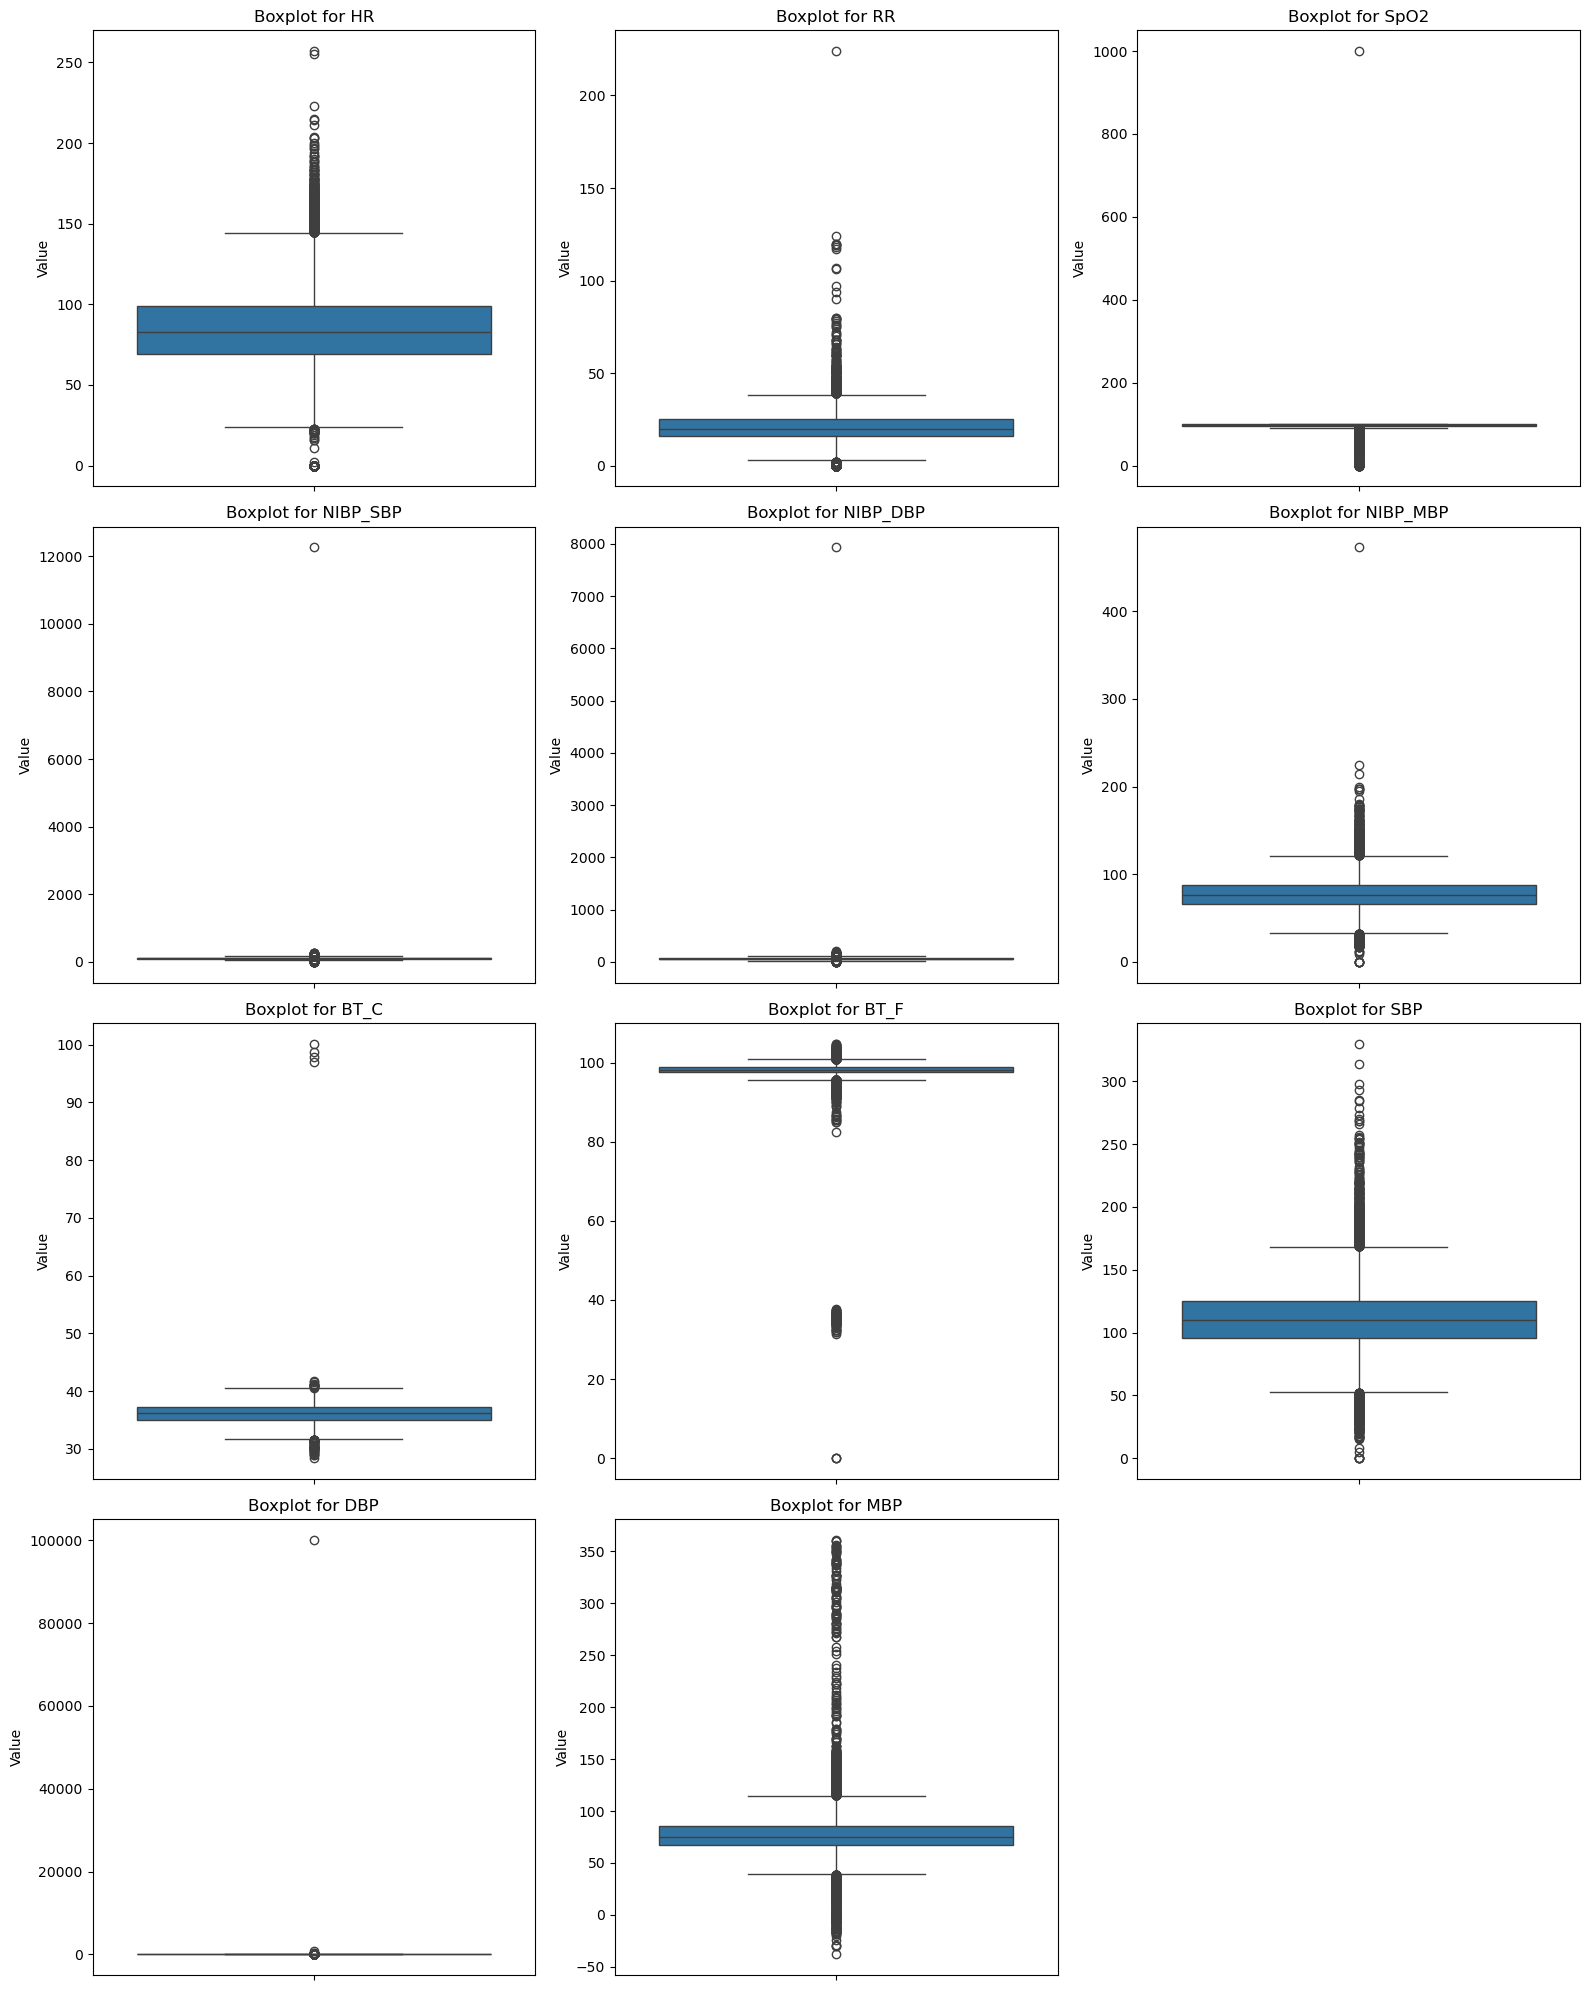

In [48]:
# Get unique vital signs
vitals = df_filtered['vital_sign'].unique()

# Set up the plot grid
num_vitals = len(vitals)
cols = 3
rows = (num_vitals + cols - 1) // cols  # Ceiling division
plt.figure(figsize=(16, 5 * rows))

# Loop through each vital sign
for i, vital in enumerate(vitals, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(y='valuenum', data=df_filtered[df_filtered['vital_sign'] == vital])
    plt.title(f'Boxplot for {vital}')
    plt.ylabel('Value')
    plt.tight_layout()

plt.show()

In [49]:
# Step 1: Extract only the BT_F records
bt_f_df = df_filtered[df_filtered['vital_sign'] == 'BT_F']

# Step 2: Define a suspicious range — likely entered in °C but labeled as °F
# Celsius 30–45 mistakenly entered as Fahrenheit = 30°F–45°F
# That would actually be fatal body temps, so definitely wrong
suspected_mislabelled_bt_f = bt_f_df[(bt_f_df['valuenum'] >= 30) & (bt_f_df['valuenum'] <= 45)]

# Step 3: See how many there are
print(f"⚠️ Suspected Celsius-as-Fahrenheit entries: {len(suspected_mislabelled_bt_f)}")

# Optional: Preview some of them
suspected_mislabelled_bt_f.head()

⚠️ Suspected Celsius-as-Fahrenheit entries: 72


,subject_id,hadm_id,stay_id,itemid,valuenum,vital_sign
63304,10271174,26331353,34802446,223761,34.5,BT_F
91111,10360829,25182118,35548232,223761,34.7,BT_F
110487,10421957,23968382,33607155,223761,32.9,BT_F
110502,10421957,23968382,33607155,223761,31.3,BT_F
111129,10421957,23968382,33607155,223761,32.0,BT_F


In [50]:
suspected_mislabelled_bt_f["subject_id"].nunique()

46

In [51]:
# Celsius itemid and label
bt_c_itemid = 223762
bt_c_label = 'BT_C'

# Create a mask for the suspicious Fahrenheit temps
suspect_mask = (df_filtered['vital_sign'] == 'BT_F') & \
               (df_filtered['valuenum'] >= 30) & \
               (df_filtered['valuenum'] <= 45)

# Apply corrections
df_filtered.loc[suspect_mask, 'itemid'] = bt_c_itemid   # “For all rows where suspect_mask is True, change the itemid to 223762.”
df_filtered.loc[suspect_mask, 'vital_sign'] = bt_c_label # “For the same rows, also update the vital_sign label to 'BT_C'.”

# Confirm changes
print(f"✅ Corrected {suspect_mask.sum()} mislabeled BT_F values to BT_C")

✅ Corrected 72 mislabeled BT_F values to BT_C


In [52]:
df_filtered[suspect_mask][['subject_id', 'stay_id', 'itemid', 'vital_sign', 'valuenum']].head()

,subject_id,stay_id,itemid,vital_sign,valuenum
63304,10271174,34802446,223762,BT_C,34.5
91111,10360829,35548232,223762,BT_C,34.7
110487,10421957,33607155,223762,BT_C,32.9
110502,10421957,33607155,223762,BT_C,31.3
111129,10421957,33607155,223762,BT_C,32.0


In [53]:
# Define acceptable ranges
acceptable_ranges = {
    'HR': (30, 202),
    'SBP': (50, 250),
    'DBP': (30, 150),
    'MBP': (40, 150),
    'RR': (5, 50),
    'BT_C': (30, 45),   # https://en.wikipedia.org/wiki/Human_body_temperature#:~:text=44%20%C2%B0C%20(111.2%20%C2%B0,respiratory%20collapse%20will%20likely%20occur.
    'BT_F': (86, 113),
    'SpO2': (50, 110),
    'NIBP_SBP': (50, 250),
    'NIBP_DBP': (30, 150),
    'NIBP_MBP': (40, 150)
}

# Function to filter outliers
def filter_outliers(row):
    lower, upper = acceptable_ranges[row['vital_sign']]
    if pd.notnull(row['valuenum']) and (row['valuenum'] < lower or row['valuenum'] > upper):
        return None
    return row['valuenum']

# Apply the filter function
df_filtered['valuenum'] = df_filtered.apply(filter_outliers, axis=1)

# Drop rows where valuenum is None (i.e., outliers)
df_cleaned = df_filtered.dropna(subset=['valuenum'])

In [54]:
df_cleaned.groupby("vital_sign")["valuenum"].describe()

,count,mean,std,min,25%,50%,75%,max
vital_sign,,,,,,,,
BT_C,5073.0,36.014932,1.722502,30.0,35.0,36.3,37.2,41.7
BT_F,9618.0,98.277828,1.464638,86.3,97.6,98.2,98.9,104.8
DBP,27663.0,60.324007,14.181986,30.0,51.0,59.0,68.0,149.0
HR,63524.0,85.456300,22.267996,30.0,69.0,83.0,99.0,200.0
MBP,27610.0,77.859037,15.786488,40.0,67.0,76.0,86.0,150.0
NIBP_DBP,34073.0,65.461920,16.685560,30.0,54.0,64.0,75.0,149.0
NIBP_MBP,34142.0,77.884219,16.685842,40.0,66.0,76.0,88.0,150.0
NIBP_SBP,34458.0,114.312641,24.006121,50.0,98.0,111.0,128.0,250.0
RR,61696.0,20.894321,6.081862,5.0,16.0,20.0,25.0,50.0


In [55]:
print("Total number of observations:", len(df_filtered))
print("Total unique ICU stays (stay_id):", df_filtered["stay_id"].nunique())
print("Total unique patients (subject_id):", df_filtered["subject_id"].nunique())
print("\nFirst few rows of the dataset:")
df_filtered.head()

Total number of observations: 388531
Total unique ICU stays (stay_id): 2302
Total unique patients (subject_id): 2302

First few rows of the dataset:


,subject_id,hadm_id,stay_id,itemid,valuenum,vital_sign
1,10001884,26184834,37510196,220045,72.0,HR
3,10001884,26184834,37510196,220210,20.0,RR
4,10001884,26184834,37510196,220277,100.0,SpO2
5,10001884,26184834,37510196,220179,102.0,NIBP_SBP
6,10001884,26184834,37510196,220180,63.0,NIBP_DBP


In [56]:
print("Total number of observations:", len(df_cleaned))
print("Total unique ICU stays (stay_id):", df_cleaned["stay_id"].nunique())
print("Total unique patients (subject_id):", df_cleaned["subject_id"].nunique())
print("\nFirst few rows of the dataset:")
df_cleaned.head()

Total number of observations: 384272
Total unique ICU stays (stay_id): 2301
Total unique patients (subject_id): 2301

First few rows of the dataset:


,subject_id,hadm_id,stay_id,itemid,valuenum,vital_sign
1,10001884,26184834,37510196,220045,72.0,HR
3,10001884,26184834,37510196,220210,20.0,RR
4,10001884,26184834,37510196,220277,100.0,SpO2
5,10001884,26184834,37510196,220179,102.0,NIBP_SBP
6,10001884,26184834,37510196,220180,63.0,NIBP_DBP


In [57]:
# Count per vital sign BEFORE cleaning. sort_index() → sorts the result alphabetically by the index (which is vital_sign, like 'BT_C', 'HR', etc.).
before_counts = df_filtered['vital_sign'].value_counts().sort_index()

# Count per vital sign AFTER cleaning
after_counts = df_cleaned['vital_sign'].value_counts().sort_index()

# Combine into a summary DataFrame
summary = pd.DataFrame({
    'Before_Cleaning': before_counts,
    'After_Cleaning': after_counts
})

# Calculate number and percentage of removed outliers
summary['Removed'] = summary['Before_Cleaning'] - summary['After_Cleaning']
summary['Percent_Removed'] = (summary['Removed'] / summary['Before_Cleaning'] * 100).round(2)

# Display the summary
summary

,Before_Cleaning,After_Cleaning,Removed,Percent_Removed
vital_sign,,,,
BT_C,5090,5073,17,0.33
BT_F,9628,9618,10,0.10
DBP,28053,27663,390,1.39
HR,63822,63524,298,0.47
MBP,28426,27610,816,2.87
NIBP_DBP,34592,34073,519,1.50
NIBP_MBP,34646,34142,504,1.45
NIBP_SBP,34607,34458,149,0.43
RR,62783,61696,1087,1.73


In [58]:
# Count how many stay_ids were dropped per vital sign
stay_ids_before = df_filtered.groupby('vital_sign')['stay_id'].nunique()
stay_ids_after = df_cleaned.groupby('vital_sign')['stay_id'].nunique()

# Calculate difference in stay_id counts
stay_ids_removed = stay_ids_before - stay_ids_after

# Add to summary table
summary['Stay_IDs_Before'] = stay_ids_before
summary['Stay_IDs_After'] = stay_ids_after
summary['Stay_IDs_Removed'] = stay_ids_removed
summary['Percent_Stay_IDs_Removed'] = (stay_ids_removed / stay_ids_before * 100).round(2)

# Rearranging for better readability (optional)
summary = summary[[
    'Before_Cleaning', 'After_Cleaning', 'Removed', 'Percent_Removed',
    'Stay_IDs_Before', 'Stay_IDs_After', 'Stay_IDs_Removed', 'Percent_Stay_IDs_Removed'
]]

# Display the updated summary
summary

,Before_Cleaning,After_Cleaning,Removed,Percent_Removed,Stay_IDs_Before,Stay_IDs_After,Stay_IDs_Removed,Percent_Stay_IDs_Removed
vital_sign,,,,,,,,
BT_C,5090,5073,17,0.33,558,556,2,0.36
BT_F,9628,9618,10,0.10,1688,1686,2,0.12
DBP,28053,27663,390,1.39,1206,1195,11,0.91
HR,63822,63524,298,0.47,2302,2301,1,0.04
MBP,28426,27610,816,2.87,1219,1195,24,1.97
NIBP_DBP,34592,34073,519,1.50,2017,2006,11,0.55
NIBP_MBP,34646,34142,504,1.45,2016,2005,11,0.55
NIBP_SBP,34607,34458,149,0.43,2017,2013,4,0.20
RR,62783,61696,1087,1.73,2294,2293,1,0.04


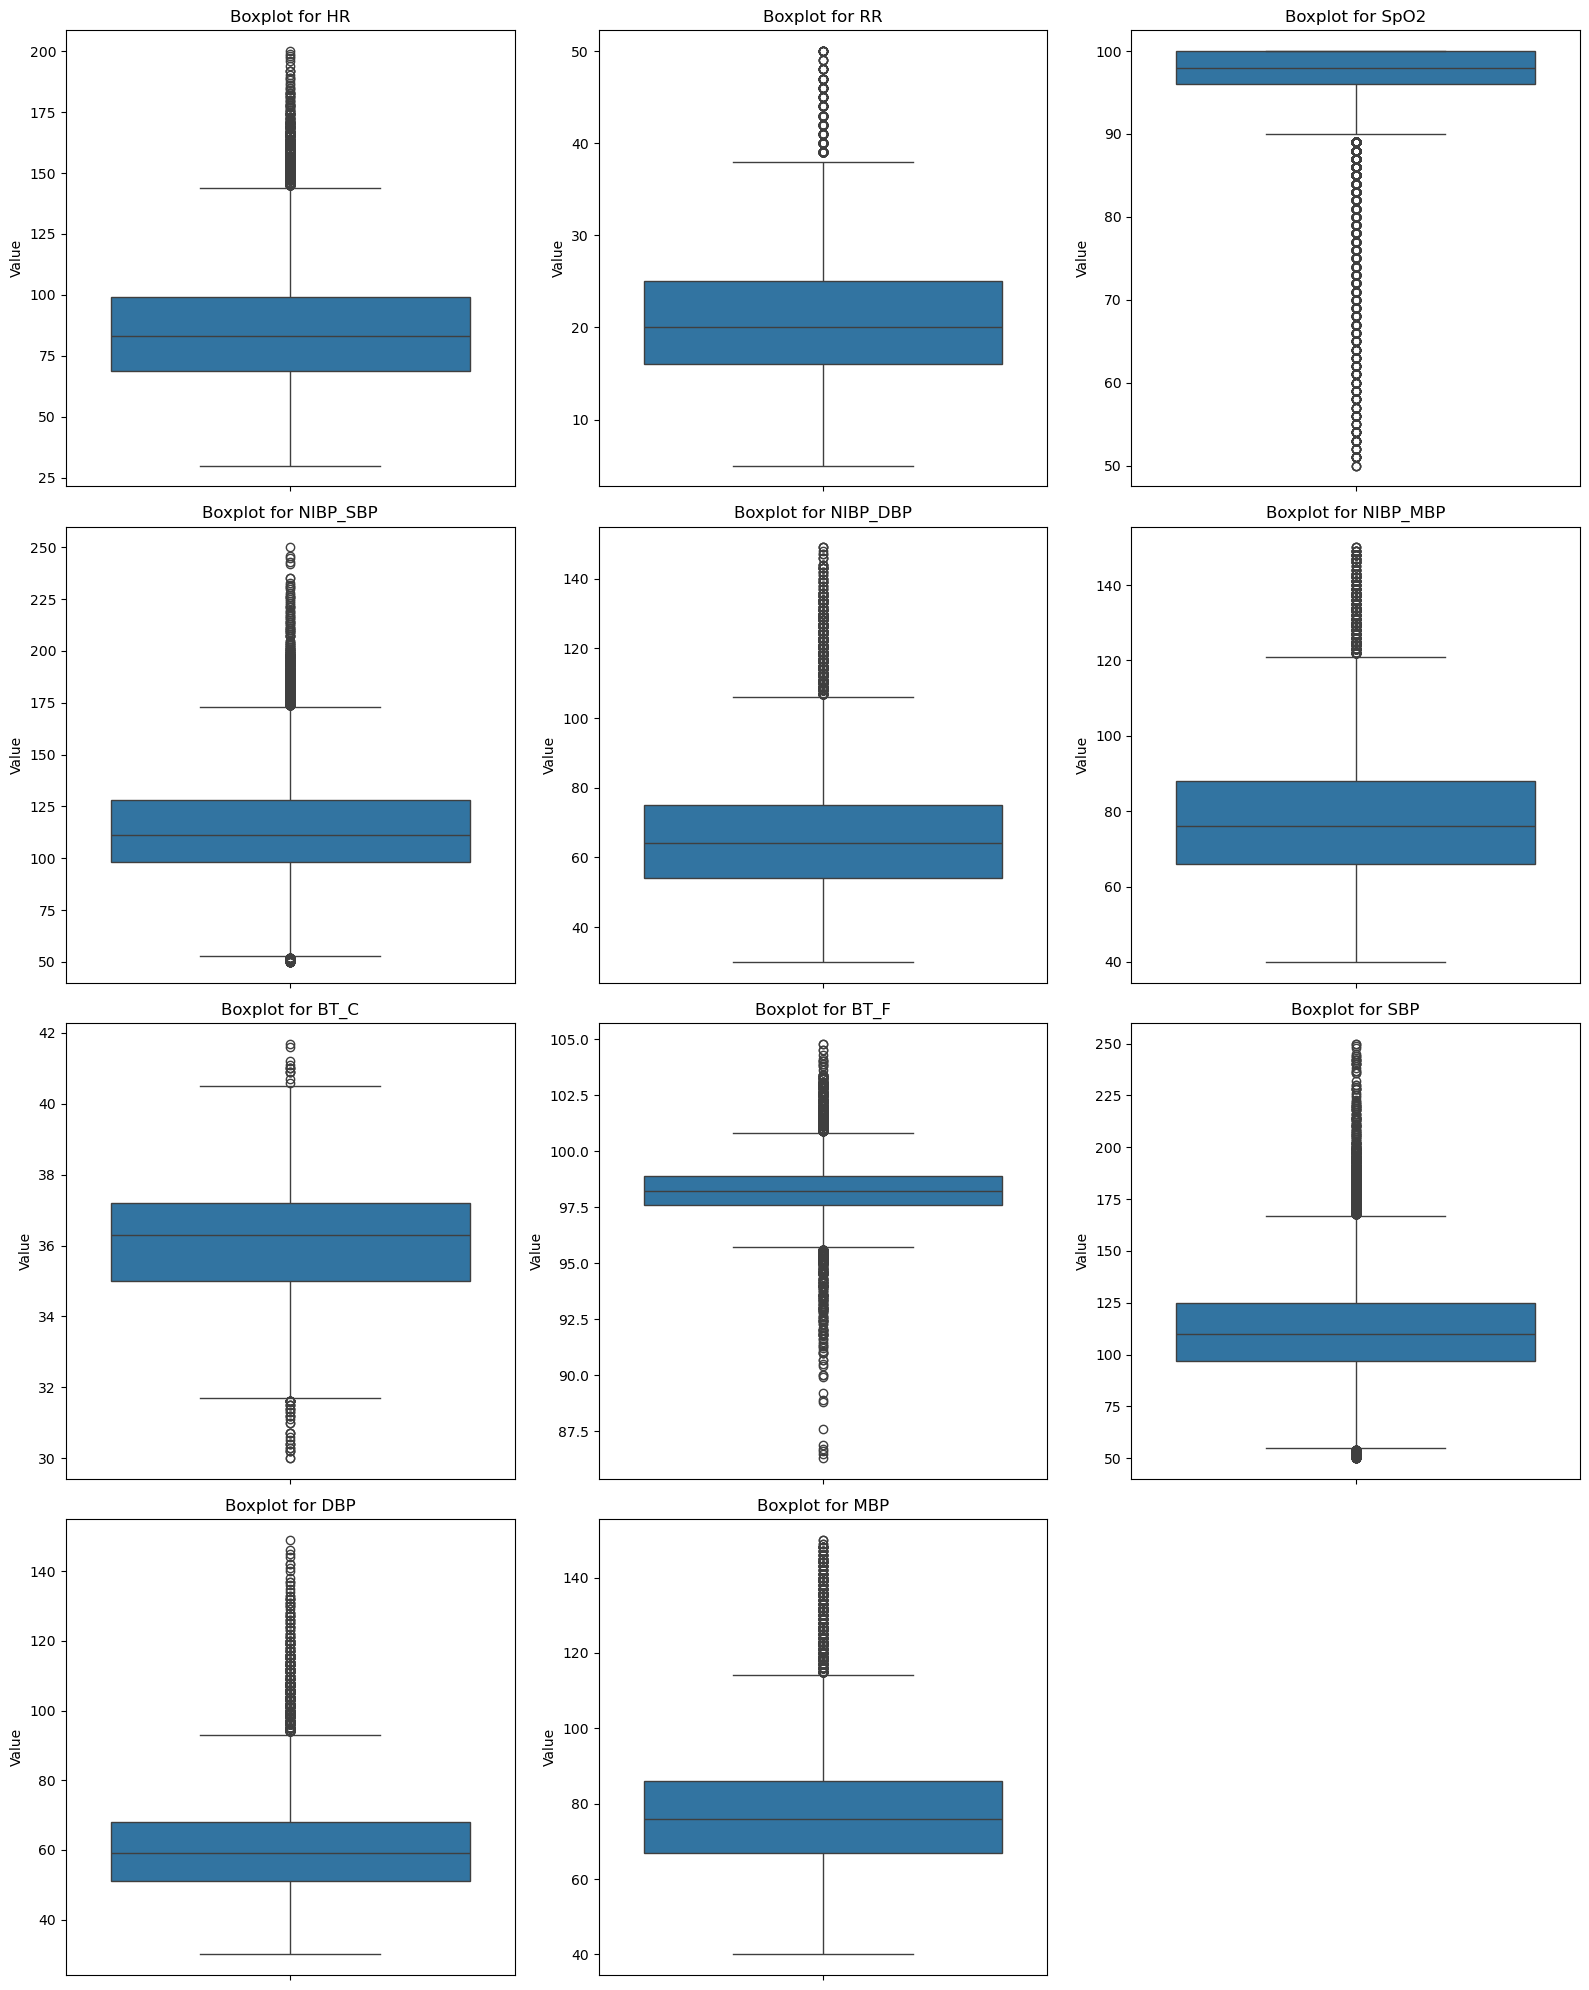

In [59]:
# Get unique vital signs
vitals = df_cleaned['vital_sign'].unique()

# Set up the plot grid
num_vitals = len(vitals)
cols = 3
rows = (num_vitals + cols - 1) // cols  # Ceiling division
plt.figure(figsize=(16, 5 * rows))

# Loop through each vital sign
for i, vital in enumerate(vitals, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(y='valuenum', data=df_cleaned[df_cleaned['vital_sign'] == vital])
    plt.title(f'Boxplot for {vital}')
    plt.ylabel('Value')
    plt.tight_layout()

plt.show()

In [60]:
df_cleaned.to_csv(f"{output__path}temp_vital_signs.csv", index=False)

### enrich vital signs

In [61]:
# Start timer
start_time_part2 = time.time()

# Define paths
temp_filtered_path = f"{output__path}temp_vital_signs.csv"
ca_patients_filtered_path = f"{output__path}ca_patients_filtered.csv"
output_path = f"{output__path}vitals_summary.csv"

# Load entire filtered dataset using Pandas
filtered_pandas_df = pd.read_csv(temp_filtered_path)

# Convert to cuDF for GPU processing
#filtered_cudf_df = cudf.DataFrame.from_pandas(filtered_pandas_df)

# Group by and compute aggregates (all data in GPU memory)
final_vitals_df = filtered_pandas_df.groupby(['subject_id', 'hadm_id', 'stay_id', 'itemid']).agg({
    'valuenum': ['mean', 'min', 'max']
}).reset_index()

# Flatten column names
final_vitals_df.columns = ['subject_id', 'hadm_id', 'stay_id', 'itemid', 'average_value', 'min_value', 'max_value']

# Load CA patients data with additional columns (excluding 'intime', 'outtime')
ca_patients_additional = pd.read_csv(
    ca_patients_filtered_path,
    usecols=['subject_id', 'hadm_id', 'stay_id', 'icd_code', 
             'gender', 'anchor_age', 'anchor_year', 'anchor_year_group', 'dod', 'survival_status']
)
#ca_patients_additional = cudf.DataFrame.from_pandas(ca_patients_additional)

# Merge aggregated vitals with patient metadata
final_vitals_df = final_vitals_df.merge(
    ca_patients_additional,
    on=['subject_id', 'hadm_id', 'stay_id'],
    how='left'  # Ensure all vitals rows are preserved
)

# Convert to Pandas and save to CSV
final_vitals_df.to_csv(output_path, index=False)

# Clean up temporary file
if os.path.exists(temp_filtered_path):
    os.remove(temp_filtered_path)

# End timer and report
end_time_part2 = time.time()
elapsed_time_part2 = (end_time_part2 - start_time_part2) / 60


print(f"✅ Processed {final_vitals_df.shape[0]} rows and saved to {output_path}")
print(f"⏳ Part 2 execution time: {elapsed_time_part2:.2f} minutes")

✅ Processed 18718 rows and saved to ../Outputs/vitals_summary.csv
⏳ Part 2 execution time: 0.00 minutes


In [62]:
print(final_vitals_df["stay_id"].nunique())
final_vitals_df.head()

2301


,subject_id,hadm_id,stay_id,itemid,average_value,min_value,max_value,icd_code,gender,anchor_age,anchor_year,anchor_year_group,dod,survival_status
0,10001884,26184834,37510196,220045,71.392857,38.0,80.0,I469,F,68,2122,2008 - 2010,2131-01-20 05:15:00,1
1,10001884,26184834,37510196,220179,123.730769,93.0,180.0,I469,F,68,2122,2008 - 2010,2131-01-20 05:15:00,1
2,10001884,26184834,37510196,220180,75.320000,49.0,123.0,I469,F,68,2122,2008 - 2010,2131-01-20 05:15:00,1
3,10001884,26184834,37510196,220181,86.038462,46.0,130.0,I469,F,68,2122,2008 - 2010,2131-01-20 05:15:00,1
4,10001884,26184834,37510196,220210,17.357143,10.0,26.0,I469,F,68,2122,2008 - 2010,2131-01-20 05:15:00,1


In [63]:
# Check for exact duplicates considering 'subject_id', 'hadm_id', 'stay_id', and 'itemid'
duplicates_with_itemid = final_vitals_df[final_vitals_df.duplicated(subset=['subject_id', 'hadm_id', 'stay_id', 'itemid'], keep=False)]

# Get the number of duplicate rows
num_duplicates = duplicates_with_itemid.shape[0]
print(f"Number of duplicate rows (with itemid): {num_duplicates}")

Number of duplicate rows (with itemid): 0


In [64]:
# Define vital sign item IDs and corresponding labels
vital_itemids = {
    220045: 'HR',   # Heart Rate
    220050: 'SBP',  # Systolic BP (Arterial)
    220051: 'DBP',  # Diastolic BP (Arterial)
    220052: 'MBP',  # Mean BP (Arterial)
    220210: 'RR',   # Respiratory Rate
    223762: 'BT',   # Body Temperature (Celsius)
    220277: 'SpO2'  # SpO2
}


# Load the vitals_summary dataset using Pandas
vital_path = f"{output__path}vitals_summary.csv"
vital_df = pd.read_csv(vital_path)

# 🔹 Step 1: Filter only the itemids that we care about
vital_filtered = vital_df[vital_df['itemid'].isin(vital_itemids.keys())]

# 🔹 Step 2: Pivot to convert itemid values into separate columns
vital_pivot = vital_filtered.pivot(index=['subject_id', 'hadm_id', 'stay_id'], 
                                   columns='itemid', 
                                   values='average_value').reset_index()

# 🔹 Step 3: Rename itemid columns to meaningful names
vital_pivot = vital_pivot.rename(columns=vital_itemids)

# 🔹 Step 4: Merge with additional patient info
additional_columns = ['icd_code', 'gender', 'anchor_age', 'anchor_year', 'anchor_year_group', 'dod', 'survival_status']
patient_info = vital_df[['subject_id', 'hadm_id', 'stay_id'] + additional_columns].drop_duplicates()

final_df = vital_pivot.merge(patient_info, on=['subject_id', 'hadm_id', 'stay_id'], how='left')

# 🔹 Step 5: Reorder columns
desired_order = ['subject_id', 'hadm_id', 'stay_id', 'HR', 'SBP', 'DBP', 'MBP', 'RR', 'BT', 'SpO2', 
                 'icd_code', 'gender', 'anchor_age', 'anchor_year', 'anchor_year_group', 'dod', 'survival_status']
final_df = final_df[desired_order]

# 🔹 Step 6: Save final dataframe
output_path = f"{output__path}vitals_final_summary.csv"
final_df.to_csv(output_path, index=False)

print(f"✅ Final dataframe saved to {output_path}.")

print(f"Total Number of Observations: {len(final_df)}")
print(f"Total Number of Unique Patients: {final_df['subject_id'].nunique()}")
print(f"Total Hospital Admissions Identified: {final_df['hadm_id'].nunique()}")
print(f"Total ICU Admissions Identified: {final_df['stay_id'].nunique()}")

✅ Final dataframe saved to ../Outputs/vitals_final_summary.csv.
Total Number of Observations: 2301
Total Number of Unique Patients: 2301
Total Hospital Admissions Identified: 2301
Total ICU Admissions Identified: 2301


In [65]:
print(final_df["stay_id"].nunique())
final_df.head()

2301


,subject_id,hadm_id,stay_id,HR,SBP,DBP,MBP,RR,BT,SpO2,icd_code,gender,anchor_age,anchor_year,anchor_year_group,dod,survival_status
0,10001884,26184834,37510196,71.392857,NaN,NaN,NaN,17.357143,36.573684,98.259259,I469,F,68,2122,2008 - 2010,2131-01-20 05:15:00,1
1,10009823,22096005,31805686,106.461538,NaN,NaN,NaN,25.333333,NaN,96.357143,I469,F,45,2150,2020 - 2022,2150-12-06 14:22:00,1
2,10010471,29842315,32119961,86.920000,NaN,NaN,NaN,15.880000,NaN,97.480000,I462,F,89,2155,2014 - 2016,2155-12-07 15:30:00,1
3,10013569,27993048,38857852,80.285714,NaN,NaN,NaN,17.333333,36.321053,96.037037,4275,F,54,2165,2008 - 2010,NaN,0
4,10021454,29492087,33300154,57.920000,110.121212,55.393939,75.636364,20.120000,35.708000,99.920000,I469,M,88,2125,2020 - 2022,2125-03-24 16:43:00,1


In [66]:
ca_patients_path=f'{output__path}ca_patients_filtered.csv'

In [67]:
ca_patients = pd.read_csv(ca_patients_path)
len(ca_patients)

2307

In [68]:
# Merge final_df into ca_patients using a left join
# Define join keys
join_keys = ['subject_id', 'hadm_id', 'stay_id']

# Get only columns in final_df that are NOT in ca_patients (excluding join keys)
final_df_extra_cols = [col for col in final_df.columns 
                       if col not in ca_patients.columns or col in join_keys]

# Merge: preserve all info from ca_patients, and only add new info from final_df
final_df_expanded = ca_patients.merge(final_df[final_df_extra_cols], on=join_keys, how='left')

print(len(final_df_expanded))
final_df_expanded.head()

2307


,subject_id,hadm_id,icd_code,stay_id,intime,outtime,los,gender,anchor_age,anchor_year,...,deathtime,dod,survival_status,HR,SBP,DBP,MBP,RR,BT,SpO2
0,10001884,26184834,I469,37510196,2131-01-11 04:20:05,2131-01-20 08:27:30,9.171817,F,68,2122,...,2131-01-20 05:15:00,2131-01-20 05:15:00,1,71.392857,NaN,NaN,NaN,17.357143,36.573684,98.259259
1,10009823,22096005,I469,31805686,2150-12-06 06:46:10,2150-12-06 20:33:52,0.574792,F,45,2150,...,2150-12-06 14:22:00,2150-12-06 14:22:00,1,106.461538,NaN,NaN,NaN,25.333333,NaN,96.357143
2,10010471,29842315,I462,32119961,2155-12-02 20:33:00,2155-12-07 18:19:18,4.907153,F,89,2155,...,2155-12-07 15:30:00,2155-12-07 15:30:00,1,86.920000,NaN,NaN,NaN,15.880000,NaN,97.480000
3,10013569,27993048,4275,38857852,2167-11-26 16:26:07,2167-12-05 16:53:53,9.019282,F,54,2165,...,NaN,NaN,0,80.285714,NaN,NaN,NaN,17.333333,36.321053,96.037037
4,10021454,29492087,I469,33300154,2125-03-17 02:41:26,2125-03-24 20:18:57,7.734387,M,88,2125,...,2125-03-24 16:43:00,2125-03-24 16:43:00,1,57.920000,110.121212,55.393939,75.636364,20.120000,35.708000,99.920000


In [69]:
missing_ids = set(ca_patients['stay_id']) - set(final_df_expanded['stay_id'])
print("Missing stay_ids:", missing_ids)

Missing stay_ids: set()


In [70]:
final_df = final_df_expanded.copy()

In [71]:
# List of vital sign columns to check
vital_columns = ['HR', 'SBP', 'DBP', 'MBP', 'RR', 'BT', 'SpO2']

# Calculate missing value percentages
missing_percent = final_df[vital_columns].isna().mean() * 100

# Print results with formatting
print("Percentage of missing values per column:")
print(missing_percent.round(2).to_string())

Percentage of missing values per column:
HR       0.26
SBP     48.11
DBP     48.20
MBP     48.20
RR       0.61
BT      75.90
SpO2     1.56


In [72]:
# Define vital sign item IDs and corresponding labels

vital_itemids = {
    220045: 'HR',   # Heart Rate
    220179: 'SBP',  # Non Invasive Blood Pressure systolic
    220180: 'DBP',  # Non Invasive Blood Pressure diastolic
    220181: 'MBP',  # Non Invasive Blood Pressure mean
    220210: 'RR',   # Respiratory Rate
    223761: 'BT',   # Temperature Fahrenheit
    220277: 'SpO2'  # SpO2
}

# Load the vitals_summary dataset using Pandas
vital_path = f"{output__path}vitals_summary.csv"
vital_df = pd.read_csv(vital_path)

# 🔹 Step 1: Filter only the itemids that we care about
vital_filtered = vital_df[vital_df['itemid'].isin(vital_itemids.keys())]

# 🔹 Step 2: Pivot to convert itemid values into separate columns
vital_pivot = vital_filtered.pivot(index=['subject_id', 'hadm_id', 'stay_id'], 
                                   columns='itemid', 
                                   values='average_value').reset_index()

# 🔹 Step 3: Rename itemid columns to meaningful names
vital_pivot = vital_pivot.rename(columns=vital_itemids)

# 🔹 Step 4: Merge with additional patient info
additional_columns = ['icd_code', 'gender', 'anchor_age', 'anchor_year', 'anchor_year_group', 'dod']
patient_info = vital_df[['subject_id', 'hadm_id', 'stay_id'] + additional_columns].drop_duplicates()

final_df = vital_pivot.merge(patient_info, on=['subject_id', 'hadm_id', 'stay_id'], how='left')

# 🔹 Step 5: Reorder columns
desired_order = ['subject_id', 'hadm_id', 'stay_id', 'HR', 'SBP', 'DBP', 'MBP', 'RR', 'BT', 'SpO2', 
                 'icd_code', 'gender', 'anchor_age', 'anchor_year', 'anchor_year_group', 'dod']
final_df = final_df[desired_order]

# 🔹 Step 6: Save final dataframe
output_path = f"{output__path}vitals_final_summary.csv"
final_df.to_csv(output_path, index=False)

print(f"✅ Final dataframe saved to {output_path}.")

print(f"Total Number of Observations: {len(final_df)}")
print(f"Total Number of Unique Patients: {final_df['subject_id'].nunique()}")
print(f"Total Hospital Admissions Identified: {final_df['hadm_id'].nunique()}")
print(f"Total ICU Admissions Identified: {final_df['stay_id'].nunique()}")

✅ Final dataframe saved to ../Outputs/vitals_final_summary.csv.
Total Number of Observations: 2301
Total Number of Unique Patients: 2301
Total Hospital Admissions Identified: 2301
Total ICU Admissions Identified: 2301


In [73]:
ca_patients = pd.read_csv(ca_patients_path)
len(ca_patients)

2307

In [74]:
# Merge final_df into ca_patients using a left join
# Define join keys
join_keys = ['subject_id', 'hadm_id', 'stay_id']

# Get only columns in final_df that are NOT in ca_patients (excluding join keys)
final_df_extra_cols = [col for col in final_df.columns 
                       if col not in ca_patients.columns or col in join_keys]

# Merge: preserve all info from ca_patients, and only add new info from final_df
final_df_expanded = ca_patients.merge(final_df[final_df_extra_cols], on=join_keys, how='left')

print(len(final_df_expanded))
final_df_expanded.head()

2307


,subject_id,hadm_id,icd_code,stay_id,intime,outtime,los,gender,anchor_age,anchor_year,...,deathtime,dod,survival_status,HR,SBP,DBP,MBP,RR,BT,SpO2
0,10001884,26184834,I469,37510196,2131-01-11 04:20:05,2131-01-20 08:27:30,9.171817,F,68,2122,...,2131-01-20 05:15:00,2131-01-20 05:15:00,1,71.392857,123.730769,75.320000,86.038462,17.357143,NaN,98.259259
1,10009823,22096005,I469,31805686,2150-12-06 06:46:10,2150-12-06 20:33:52,0.574792,F,45,2150,...,2150-12-06 14:22:00,2150-12-06 14:22:00,1,106.461538,111.900000,73.545455,84.090909,25.333333,97.533333,96.357143
2,10010471,29842315,I462,32119961,2155-12-02 20:33:00,2155-12-07 18:19:18,4.907153,F,89,2155,...,2155-12-07 15:30:00,2155-12-07 15:30:00,1,86.920000,104.840000,54.280000,65.880000,15.880000,97.880000,97.480000
3,10013569,27993048,4275,38857852,2167-11-26 16:26:07,2167-12-05 16:53:53,9.019282,F,54,2165,...,NaN,NaN,0,80.285714,108.640000,59.080000,70.000000,17.333333,98.400000,96.037037
4,10021454,29492087,I469,33300154,2125-03-17 02:41:26,2125-03-24 20:18:57,7.734387,M,88,2125,...,2125-03-24 16:43:00,2125-03-24 16:43:00,1,57.920000,NaN,NaN,NaN,20.120000,96.500000,99.920000


In [75]:
missing_ids = set(ca_patients['stay_id']) - set(final_df_expanded['stay_id'])
print("Missing stay_ids:", missing_ids)

Missing stay_ids: set()


In [76]:
final_df = final_df_expanded.copy()

In [77]:
# List of vital sign columns to check
vital_columns = ['HR', 'SBP', 'DBP', 'MBP', 'RR', 'BT', 'SpO2']

# Calculate missing value percentages
missing_percent = final_df[vital_columns].isna().mean() * 100

# Print results with formatting
print("Percentage of missing values per column:")
print(missing_percent.round(2).to_string())

Percentage of missing values per column:
HR       0.26
SBP     12.74
DBP     13.05
MBP     13.09
RR       0.61
BT      26.92
SpO2     1.56


In [78]:
vital_df.head()

,subject_id,hadm_id,stay_id,itemid,average_value,min_value,max_value,icd_code,gender,anchor_age,anchor_year,anchor_year_group,dod,survival_status
0,10001884,26184834,37510196,220045,71.392857,38.0,80.0,I469,F,68,2122,2008 - 2010,2131-01-20 05:15:00,1
1,10001884,26184834,37510196,220179,123.730769,93.0,180.0,I469,F,68,2122,2008 - 2010,2131-01-20 05:15:00,1
2,10001884,26184834,37510196,220180,75.320000,49.0,123.0,I469,F,68,2122,2008 - 2010,2131-01-20 05:15:00,1
3,10001884,26184834,37510196,220181,86.038462,46.0,130.0,I469,F,68,2122,2008 - 2010,2131-01-20 05:15:00,1
4,10001884,26184834,37510196,220210,17.357143,10.0,26.0,I469,F,68,2122,2008 - 2010,2131-01-20 05:15:00,1


In [79]:
# Step 1: Load and Separate Non-Invasive vs Arterial Measurements

# Arterial (Invasive):
arterial_itemids = {
    220050: 'SBP_art',   # Arterial Systolic
    220051: 'DBP_art',   # Arterial Diastolic
    220052: 'MBP_art',   # Arterial Mean
    223762: 'BT_C',      # Celsius Temperature
}

# Non-Invasive + Fahrenheit:
noninvasive_itemids = {
    220179: 'SBP_nibp',  # Non-Invasive Systolic
    220180: 'DBP_nibp',  # Non-Invasive Diastolic
    220181: 'MBP_nibp',  # Non-Invasive Mean
    223761: 'BT_F',      # Fahrenheit Temperature
}

In [80]:
# Step 2: Create Two Pivoted DataFrames

# Each pivoted on subject_id, hadm_id, stay_id — one for arterial, one for non-invasive.
# Arterial
arterial_filtered = vital_df[vital_df['itemid'].isin(arterial_itemids.keys())]
arterial_pivot = arterial_filtered.pivot(index=['subject_id', 'hadm_id', 'stay_id'],
                                         columns='itemid', values='average_value').reset_index()
arterial_pivot = arterial_pivot.rename(columns=arterial_itemids)

# Non-Invasive
nibp_filtered = vital_df[vital_df['itemid'].isin(noninvasive_itemids.keys())]
nibp_pivot = nibp_filtered.pivot(index=['subject_id', 'hadm_id', 'stay_id'],
                                 columns='itemid', values='average_value').reset_index()
nibp_pivot = nibp_pivot.rename(columns=noninvasive_itemids)

In [81]:
# Step 3: Merge the Two on subject_id, hadm_id, stay_id

merged = pd.merge(nibp_pivot, arterial_pivot, on=['subject_id', 'hadm_id', 'stay_id'], how='outer')

# Now, we’ll be able to compare:
 # * Which patients have only arterial
 # * Which have only non-invasive
 # * Which have both

In [82]:
merged.head(10)

itemid,subject_id,hadm_id,stay_id,SBP_nibp,DBP_nibp,MBP_nibp,BT_F,SBP_art,DBP_art,MBP_art,BT_C
0,10001884,26184834,37510196,123.730769,75.320000,86.038462,NaN,NaN,NaN,NaN,36.573684
1,10009823,22096005,31805686,111.900000,73.545455,84.090909,97.533333,NaN,NaN,NaN,NaN
2,10010471,29842315,32119961,104.840000,54.280000,65.880000,97.880000,NaN,NaN,NaN,NaN
3,10013569,27993048,38857852,108.640000,59.080000,70.000000,98.400000,NaN,NaN,NaN,36.321053
4,10021454,29492087,33300154,NaN,NaN,NaN,96.500000,110.121212,55.393939,75.636364,35.708000
5,10022326,26237876,38860085,116.812500,60.250000,72.187500,100.650000,109.900000,50.800000,67.100000,36.320000
6,10024982,25154057,37919901,130.120000,71.583333,84.280000,98.066667,NaN,NaN,NaN,NaN
7,10026161,24614671,39625056,99.000000,63.000000,72.000000,NaN,101.800000,67.200000,79.428571,34.370833
8,10034171,28485870,34728076,102.666667,55.000000,67.000000,98.120000,96.594595,56.942857,73.000000,NaN
9,10035271,26463092,37826242,NaN,NaN,NaN,NaN,92.142857,52.857143,62.285714,31.160000


In [83]:
chartevents_filtered_path = f"{output__path}chartevents_filtered.csv"
chartevents_filtered_test = pd.read_csv(chartevents_filtered_path)
chartevents_filtered_test.head()

,subject_id,hadm_id,stay_id,caregiver_id,charttime,storetime,itemid,value,valuenum,valueuom,warning
0,10001884,26184834,37510196,2091.0,2131-01-18 04:19:00,2131-01-18 05:19:00,227944,3 rails up,NaN,NaN,0.0
1,10001884,26184834,37510196,2091.0,2131-01-18 04:19:00,2131-01-18 05:19:00,227945,On,NaN,NaN,0.0
2,10001884,26184834,37510196,2091.0,2131-01-18 04:19:00,2131-01-18 05:19:00,227946,Done,NaN,NaN,0.0
3,10001884,26184834,37510196,2091.0,2131-01-18 04:19:00,2131-01-18 05:19:00,227947,Treatment interference,NaN,NaN,0.0
4,10001884,26184834,37510196,2091.0,2131-01-18 04:19:00,2131-01-18 05:19:00,227948,Soft limb,NaN,NaN,0.0


In [84]:
chartevents_filtered_test[
    (chartevents_filtered_test["stay_id"] == 38860085) & 
    ((chartevents_filtered_test["itemid"] == 223762) | (chartevents_filtered_test["itemid"] == 223761))
]

,subject_id,hadm_id,stay_id,caregiver_id,charttime,storetime,itemid,value,valuenum,valueuom,warning
38440,10022326,26237876,38860085,55299.0,2150-06-23 14:24:00,2150-06-23 14:25:00,223761,100.9,100.9,°F,0.0
38543,10022326,26237876,38860085,70054.0,2150-06-23 16:00:00,2150-06-23 18:37:00,223761,100.9,100.9,°F,0.0
38767,10022326,26237876,38860085,70054.0,2150-06-24 08:00:00,2150-06-24 11:10:00,223762,38.6,38.6,°C,0.0
38812,10022326,26237876,38860085,70054.0,2150-06-24 11:00:00,2150-06-24 11:46:00,223762,38,38.0,°C,0.0
38828,10022326,26237876,38860085,70054.0,2150-06-24 12:00:00,2150-06-24 12:49:00,223762,36.2,36.2,°C,0.0
38932,10022326,26237876,38860085,70054.0,2150-06-24 13:00:00,2150-06-24 13:58:00,223762,34.3,34.3,°C,0.0
38958,10022326,26237876,38860085,70054.0,2150-06-24 14:00:00,2150-06-24 14:43:00,223762,34.5,34.5,°C,0.0
38981,10022326,26237876,38860085,70054.0,2150-06-24 15:00:00,2150-06-24 15:40:00,223762,35.5,35.5,°C,0.0
39116,10022326,26237876,38860085,99527.0,2150-06-23 19:00:00,2150-06-23 19:34:00,223761,101.7,101.7,°F,1.0
39248,10022326,26237876,38860085,99527.0,2150-06-23 20:00:00,2150-06-23 20:02:00,223761,101.3,101.3,°F,0.0


In [85]:
# 🔹 Step 0: Define vital sign item IDs and corresponding labels
vital_itemids = {
    220045: 'HR',    # Heart Rate
    220179: 'SBP',   # Non-Invasive BP systolic
    220180: 'DBP',   # Non-Invasive BP diastolic
    220181: 'MBP',   # Non-Invasive BP mean
    220210: 'RR',    # Respiratory Rate
    223761: 'BT',    # Temperature Fahrenheit
    220277: 'SpO2'   # SpO2
}

# 🔹 Step 1: Load the main vitals summary
vital_path = f"{output__path}vitals_summary.csv"
vital_df = pd.read_csv(vital_path)

# 🔹 Step 2: Filter to just the itemids we care about
vital_filtered = vital_df[vital_df['itemid'].isin(vital_itemids.keys())]

# 🔹 Step 3: Pivot to wide format
vital_pivot = vital_filtered.pivot(index=['subject_id', 'hadm_id', 'stay_id'],
                                   columns='itemid',
                                   values='average_value').reset_index()

# 🔹 Step 4: Rename itemid columns
vital_pivot = vital_pivot.rename(columns=vital_itemids)

# 🔸 Step 5: Inject additional measurements (BT in C, Arterial BP)
# BT in Celsius
bt_celsius_df = vital_df[vital_df['itemid'] == 223762]  # Celsius temperature itemid
bt_celsius_df = bt_celsius_df[['subject_id', 'hadm_id', 'stay_id', 'average_value']]
bt_celsius_df = bt_celsius_df.rename(columns={'average_value': 'BT_C'})

# Arterial BP itemids
art_bp_itemids = {
    220050: 'SBP_art',  # Invasive systolic
    220051: 'DBP_art',  # Invasive diastolic
    220052: 'MBP_art'   # Invasive mean
}
art_bp_df = vital_df[vital_df['itemid'].isin(art_bp_itemids.keys())]
art_bp_df = art_bp_df.pivot(index=['subject_id', 'hadm_id', 'stay_id'],
                            columns='itemid',
                            values='average_value').reset_index()
art_bp_df = art_bp_df.rename(columns=art_bp_itemids)

# 🔸 Step 6: Merge Celsius and Arterial BP into pivoted vitals
enriched = vital_pivot.merge(bt_celsius_df, on=['subject_id', 'hadm_id', 'stay_id'], how='left')
enriched = enriched.merge(art_bp_df, on=['subject_id', 'hadm_id', 'stay_id'], how='left')

# 🔸 Step 7: Convert Celsius to Fahrenheit and average with BT (if both present)
enriched['BT_C_to_F'] = enriched['BT_C'] * 9 / 5 + 32
enriched['BT'] = enriched[['BT', 'BT_C_to_F']].mean(axis=1)

# 🔸 Step 8: Convert arterial BP to estimated NIBP and average with existing NIBP
# SBP: IBP = 1.02 * NIBP - 2.95 → NIBP = (IBP + 2.95) / 1.02
enriched['SBP_art_to_nibp'] = (enriched['SBP_art'] + 2.95) / 1.02
enriched['SBP'] = enriched[['SBP', 'SBP_art_to_nibp']].mean(axis=1)

# DBP: IBP = 0.77 * NIBP + 18.43 → NIBP = (IBP - 18.43) / 0.77
enriched['DBP_art_to_nibp'] = (enriched['DBP_art'] - 18.43) / 0.77
enriched['DBP'] = enriched[['DBP', 'DBP_art_to_nibp']].mean(axis=1)

# MBP: Calculate from updated SBP and DBP
enriched['MBP_from_SBP_DBP'] = (enriched['SBP'] + 2 * enriched['DBP']) / 3
enriched['MBP'] = enriched[['MBP', 'MBP_from_SBP_DBP']].mean(axis=1)

# 🔸 Step 9: Attach patient demographics
additional_columns = ['icd_code', 'gender', 'anchor_age', 'anchor_year', 'anchor_year_group', 'dod', 'survival_status']
patient_info = vital_df[['subject_id', 'hadm_id', 'stay_id'] + additional_columns].drop_duplicates()
final_df = enriched.merge(patient_info, on=['subject_id', 'hadm_id', 'stay_id'], how='left')

# 🔸 Step 10: Reorder columns and drop helpers
desired_order = ['subject_id', 'hadm_id', 'stay_id', 'HR', 'SBP', 'DBP', 'MBP', 'RR', 'BT', 'SpO2',
                 'icd_code', 'gender', 'anchor_age', 'anchor_year', 'anchor_year_group', 'dod', 'survival_status']
final_df = final_df[desired_order]

# 🔸 Step 11: Save output
output_path = f"{output__path}vitals_final_summary.csv"
final_df.to_csv(output_path, index=False)

# 🔸 Final stats
print(f"✅ Final dataframe saved to {output_path}.\n")
print(f"Total Number of Observations: {len(final_df)}")
print(f"Total Number of Unique Patients: {final_df['subject_id'].nunique()}")
print(f"Total Hospital Admissions Identified: {final_df['hadm_id'].nunique()}")
print(f"Total ICU Admissions Identified: {final_df['stay_id'].nunique()}")

✅ Final dataframe saved to ../Outputs/vitals_final_summary.csv.

Total Number of Observations: 2301
Total Number of Unique Patients: 2301
Total Hospital Admissions Identified: 2301
Total ICU Admissions Identified: 2301


In [86]:
ca_patients = pd.read_csv(ca_patients_path)
# Merge final_df into ca_patients using a left join
# Define join keys
join_keys = ['subject_id', 'hadm_id', 'stay_id']

# Get only columns in final_df that are NOT in ca_patients (excluding join keys)
final_df_extra_cols = [col for col in final_df.columns 
                       if col not in ca_patients.columns or col in join_keys]

# Merge: preserve all info from ca_patients, and only add new info from final_df
final_df_expanded = ca_patients.merge(final_df[final_df_extra_cols], on=join_keys, how='left')

print(len(final_df_expanded))
final_df_expanded.head()

2307


,subject_id,hadm_id,icd_code,stay_id,intime,outtime,los,gender,anchor_age,anchor_year,...,deathtime,dod,survival_status,HR,SBP,DBP,MBP,RR,BT,SpO2
0,10001884,26184834,I469,37510196,2131-01-11 04:20:05,2131-01-20 08:27:30,9.171817,F,68,2122,...,2131-01-20 05:15:00,2131-01-20 05:15:00,1,71.392857,123.730769,75.320000,88.747692,17.357143,97.832632,98.259259
1,10009823,22096005,I469,31805686,2150-12-06 06:46:10,2150-12-06 20:33:52,0.574792,F,45,2150,...,2150-12-06 14:22:00,2150-12-06 14:22:00,1,106.461538,111.900000,73.545455,85.210606,25.333333,97.533333,96.357143
2,10010471,29842315,I462,32119961,2155-12-02 20:33:00,2155-12-07 18:19:18,4.907153,F,89,2155,...,2155-12-07 15:30:00,2155-12-07 15:30:00,1,86.920000,104.840000,54.280000,68.506667,15.880000,97.880000,97.480000
3,10013569,27993048,4275,38857852,2167-11-26 16:26:07,2167-12-05 16:53:53,9.019282,F,54,2165,...,NaN,NaN,0,80.285714,108.640000,59.080000,72.800000,17.333333,97.888947,96.037037
4,10021454,29492087,I469,33300154,2125-03-17 02:41:26,2125-03-24 20:18:57,7.734387,M,88,2125,...,2125-03-24 16:43:00,2125-03-24 16:43:00,1,57.920000,110.854130,48.005116,68.954787,20.120000,96.387200,99.920000


In [87]:
missing_ids = set(ca_patients['stay_id']) - set(final_df_expanded['stay_id'])
print("Missing stay_ids:", missing_ids)

Missing stay_ids: set()


In [88]:
final_df = final_df_expanded.copy()
final_df.head()

,subject_id,hadm_id,icd_code,stay_id,intime,outtime,los,gender,anchor_age,anchor_year,...,deathtime,dod,survival_status,HR,SBP,DBP,MBP,RR,BT,SpO2
0,10001884,26184834,I469,37510196,2131-01-11 04:20:05,2131-01-20 08:27:30,9.171817,F,68,2122,...,2131-01-20 05:15:00,2131-01-20 05:15:00,1,71.392857,123.730769,75.320000,88.747692,17.357143,97.832632,98.259259
1,10009823,22096005,I469,31805686,2150-12-06 06:46:10,2150-12-06 20:33:52,0.574792,F,45,2150,...,2150-12-06 14:22:00,2150-12-06 14:22:00,1,106.461538,111.900000,73.545455,85.210606,25.333333,97.533333,96.357143
2,10010471,29842315,I462,32119961,2155-12-02 20:33:00,2155-12-07 18:19:18,4.907153,F,89,2155,...,2155-12-07 15:30:00,2155-12-07 15:30:00,1,86.920000,104.840000,54.280000,68.506667,15.880000,97.880000,97.480000
3,10013569,27993048,4275,38857852,2167-11-26 16:26:07,2167-12-05 16:53:53,9.019282,F,54,2165,...,NaN,NaN,0,80.285714,108.640000,59.080000,72.800000,17.333333,97.888947,96.037037
4,10021454,29492087,I469,33300154,2125-03-17 02:41:26,2125-03-24 20:18:57,7.734387,M,88,2125,...,2125-03-24 16:43:00,2125-03-24 16:43:00,1,57.920000,110.854130,48.005116,68.954787,20.120000,96.387200,99.920000


In [89]:
# List of vital sign columns to check
vital_columns = ['HR', 'SBP', 'DBP', 'MBP', 'RR', 'BT', 'SpO2']

# Calculate number and percentage of missing values
missing_count = final_df[vital_columns].isna().sum()
missing_percent = final_df[vital_columns].isna().mean() * 100

# Combine into a summary DataFrame
missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_percent.round(2)
})

# Print the summary
print("🩺 Missing Values Summary:")
print(missing_summary)

🩺 Missing Values Summary:
      Missing Count  Missing %
HR                6       0.26
SBP              35       1.52
DBP              38       1.65
MBP              38       1.65
RR               14       0.61
BT              307      13.31
SpO2             36       1.56


📁 Plot saved to: ../Outputs/plots/vital_sign_distributions.png

Skewness of each variable:
HR: 0.46
SBP: 0.56
DBP: 0.38
MBP: 0.56
RR: 0.66
BT: -1.74
SpO2: -3.65


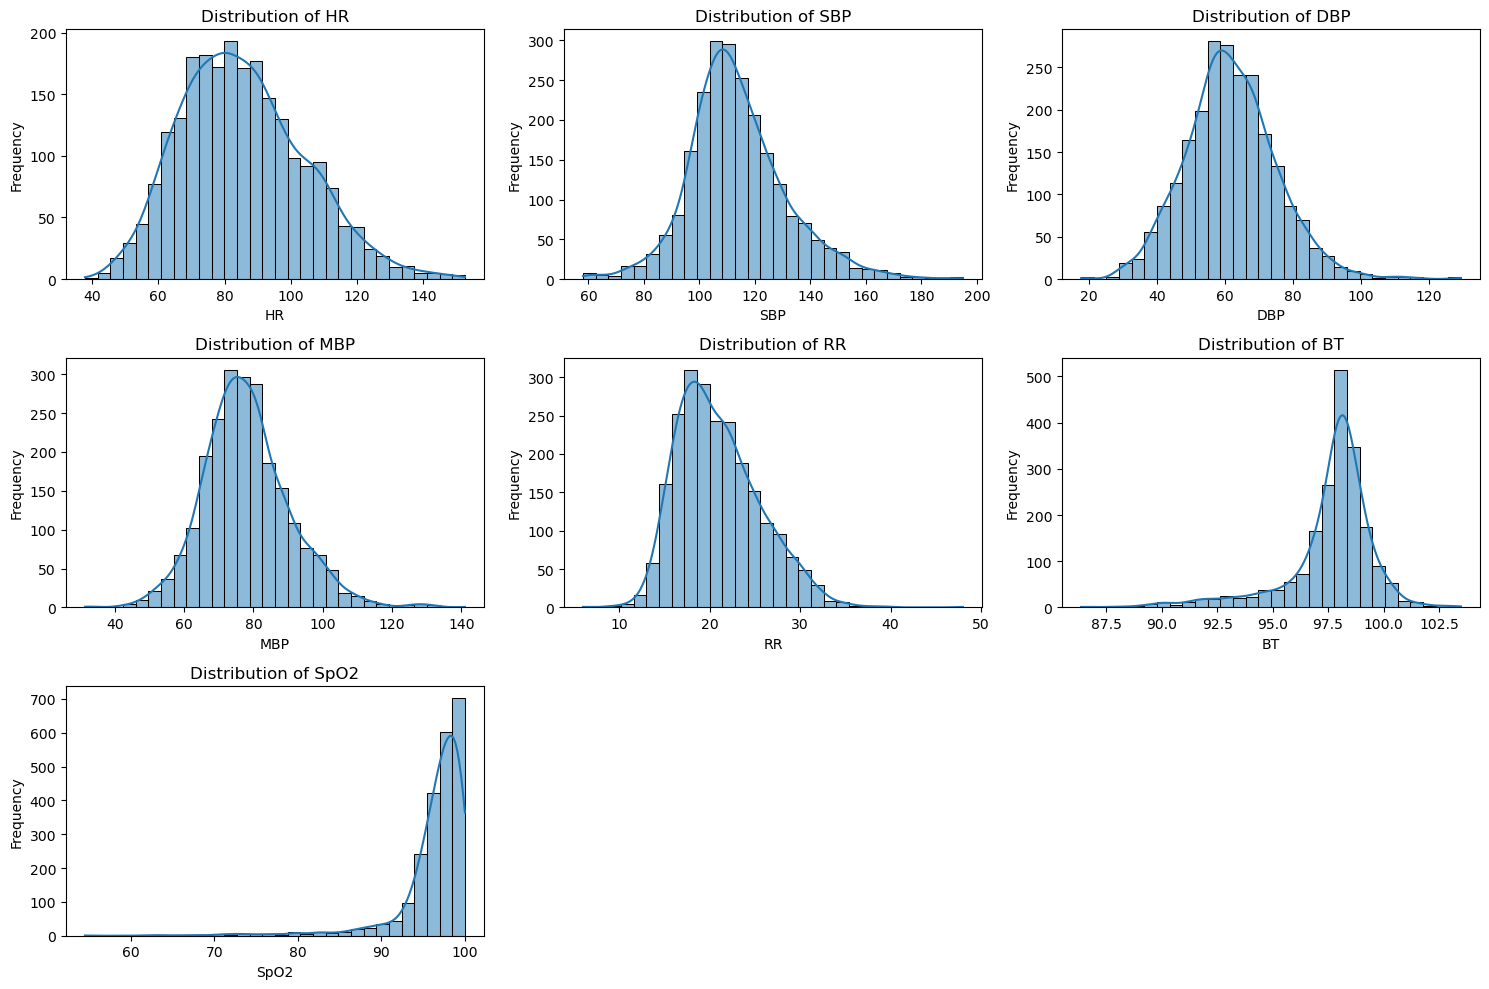

In [90]:
# List of vital sign columns to check
vital_columns = ['HR', 'SBP', 'DBP', 'MBP', 'RR', 'BT', 'SpO2']

# Set up the plot
plt.figure(figsize=(15, 10))

# Loop through each column and plot its distribution
for i, column in enumerate(vital_columns, 1):
    plt.subplot(3, 3, i)
    sns.histplot(final_df[column].dropna(), kde=True, bins=30)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')

plt.tight_layout()

# ✅ Make sure the directory exists
output_dir = f"{output__path}plots"
os.makedirs(output_dir, exist_ok=True)

# ✅ Save the figure as a high-quality PNG
output_path = os.path.join(output_dir, "vital_sign_distributions.png")
plt.savefig(output_path, dpi=300)

# Optional: also show it if you're in a notebook or GUI environment
# plt.show()

print(f"📁 Plot saved to: {output_path}")

# Check skewness for each column
print("\nSkewness of each variable:")
for column in vital_columns:
    column_skewness = skew(final_df[column].dropna())  # Drop missing values
    print(f"{column}: {column_skewness:.2f}")

In [91]:
#mean_impute_vars = ['HR', 'DBP']
#for col in mean_impute_vars:
#    final_df[col] = final_df[col].fillna(final_df[col].mean())

In [92]:
#median_impute_vars = ['SBP', 'MBP', 'RR', 'SpO2']
#for col in median_impute_vars:
#    final_df[col] = final_df[col].fillna(final_df[col].median())

In [93]:
# List of vital sign columns to check
vital_columns = ['HR', 'SBP', 'DBP', 'MBP', 'RR', 'BT', 'SpO2']

# Calculate number and percentage of missing values
missing_count = final_df[vital_columns].isna().sum()
missing_percent = final_df[vital_columns].isna().mean() * 100

# Combine into a summary DataFrame
missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_percent.round(2)
})

# Print the summary
print("🩺 Missing Values Summary:")
print(missing_summary)

🩺 Missing Values Summary:
      Missing Count  Missing %
HR                6       0.26
SBP              35       1.52
DBP              38       1.65
MBP              38       1.65
RR               14       0.61
BT              307      13.31
SpO2             36       1.56


In [94]:
output_path_preiminary = f"{output__path}vitals_signs_preliminary.csv"
final_df.to_csv(output_path_preiminary, index=False)

In [95]:
"""
# Prepare predictors and outcome
features = ['BT', 'HR', 'SBP', 'DBP', 'MBP', 'RR', 'SpO2']
target = 'survival_status' 

# Store results
coefs = []
ses = []
bt_versions = []

# Generate 5 imputed datasets
for seed in range(5):
    imputer = IterativeImputer(random_state=seed, max_iter=10, sample_posterior=True)
    
    # Fit-transform BT with other predictors
    imputed_data = imputer.fit_transform(final_df[features])
    imputed_df = pd.DataFrame(imputed_data, columns=features)
    bt_versions.append(imputed_df['BT'].copy())  # Save each version of BT
    
    # Combine imputed BT into full data
    X = final_df.copy()
    X['BT'] = imputed_df['BT']  # only BT was missing
    X = X.dropna(subset=[target])  # drop any rows where outcome is missing
    
    # Run logistic regression using statsmodels to get SE
    X_model = sm.add_constant(X[features])
    model = sm.Logit(X[target], X_model).fit(disp=0)
    
    coefs.append(model.params['BT'])
    ses.append(model.bse['BT']) # The standard errors of the parameter estimates.

#Option A: Use the first imputed version
#final_df['BT'] = bt_versions[0].values

# Option B (better): Use the average BT across imputations
final_df['BT'] = pd.concat(bt_versions, axis=1).mean(axis=1) 

"""
print('remove imputation!')

remove imputation!


In [97]:
"""
m = len(coefs)
beta_mi = np.mean(coefs)

# Within-imputation variance (average of squared SEs)
V = np.mean(np.square(ses))

# Between-imputation variance
B = np.var(coefs, ddof=1)

# Total variance
T = V + (1 + 1/m) * B

# Final SE
se_mi = np.sqrt(T)

print(f"✅ Pooled β (BT): {beta_mi:.4f}")
print(f"± SE: {se_mi:.4f}")
print(f"95% CI: [{beta_mi - 1.96 * se_mi:.4f}, {beta_mi + 1.96 * se_mi:.4f}]")
"""
print('remove imputation!')

remove imputation!


In [98]:
"""
plt.figure(figsize=(6, 4))
plt.errorbar(x=0, y=beta_mi, yerr=1.96 * se_mi, fmt='o', capsize=5, color='navy')

plt.axhline(0, color='gray', linestyle='--')
plt.xticks([0], ['BT'])
plt.ylabel('Log-Odds Coefficient')
plt.title('Pooled Effect of Body Temperature (BT)\nwith 95% Confidence Interval (Rubin\'s Rule)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("pooled_bt_effect.png", dpi=300)
plt.show()

"""
print('remove imputation!')

remove imputation!


In [99]:
"""
# Convert to numpy arrays for easy math
coefs = np.array(coefs)
ses = np.array(ses)
imputation_ids = np.arange(1, len(coefs) + 1)

# Create error bars = ±1.96 * SE (95% CI)
error = 1.96 * ses

plt.figure(figsize=(8, 5))
plt.errorbar(imputation_ids, coefs, yerr=error, fmt='o', capsize=5, color='navy', label='Imputed β (BT)')
plt.axhline(np.mean(coefs), color='orange', linestyle='--', label=f'Pooled β (mean): {np.mean(coefs):.3f}')
plt.axhline(0, color='gray', linestyle=':')

plt.title('Effect of Body Temperature (BT) on In-Hospital Mortality\nAcross 5 Imputed Datasets')
plt.xlabel('Imputation Number')
plt.ylabel('Log-Odds Coefficient for BT')
plt.xticks(imputation_ids)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("bt_coefficients_across_imputations.png", dpi=300)
plt.show()
"""
print('removed imputation!')

removed imputation!


In [100]:
# List of vital sign columns to check
vital_columns = ['HR', 'SBP', 'DBP', 'MBP', 'RR', 'BT', 'SpO2']

# Calculate number and percentage of missing values
missing_count = final_df[vital_columns].isna().sum()
missing_percent = final_df[vital_columns].isna().mean() * 100

# Combine into a summary DataFrame
missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_percent.round(2)
})

# Print the summary
print("🩺 Missing Values Summary:")
print(missing_summary)

🩺 Missing Values Summary:
      Missing Count  Missing %
HR                6       0.26
SBP              35       1.52
DBP              38       1.65
MBP              38       1.65
RR               14       0.61
BT              307      13.31
SpO2             36       1.56



Skewness of each variable:
HR: 0.46
SBP: 0.56
DBP: 0.38
MBP: 0.56
RR: 0.66
BT: -1.74
SpO2: -3.65


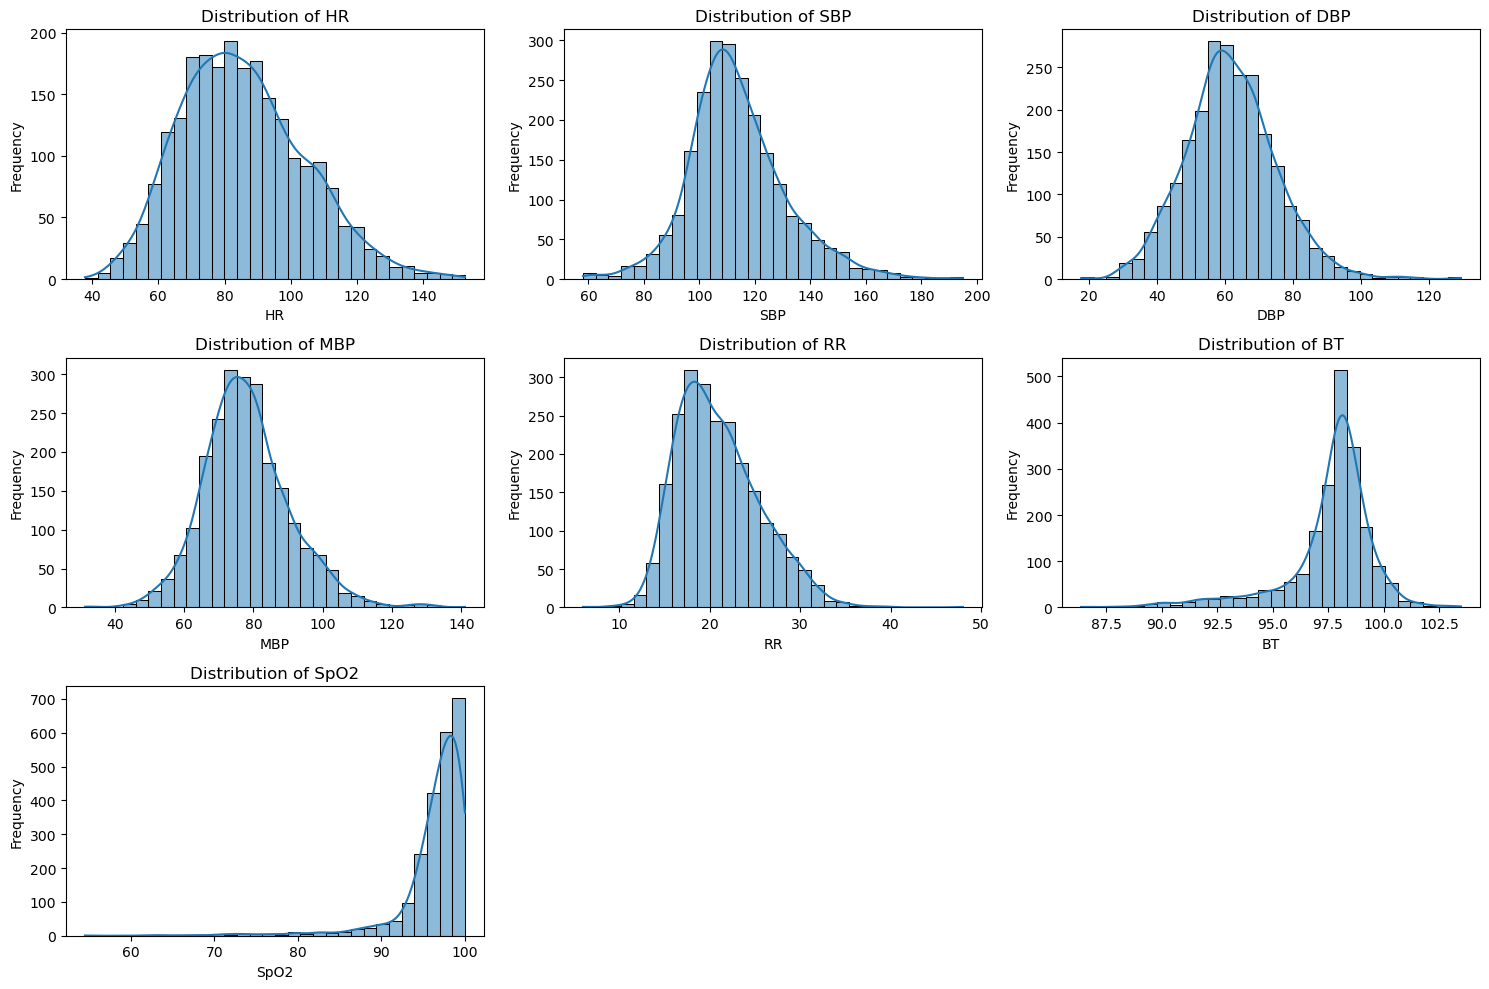

In [101]:
# List of vital sign columns to check
vital_columns = ['HR', 'SBP', 'DBP', 'MBP', 'RR', 'BT', 'SpO2']

# Set up the plot
plt.figure(figsize=(15, 10))

# Loop through each column and plot its distribution
for i, column in enumerate(vital_columns, 1):
    plt.subplot(3, 3, i)
    sns.histplot(final_df[column].dropna(), kde=True, bins=30)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')

plt.tight_layout()


# Optional: also show it if you're in a notebook or GUI environment
# plt.show()

# Check skewness for each column
print("\nSkewness of each variable:")
for column in vital_columns:
    column_skewness = skew(final_df[column].dropna())  # Drop missing values
    print(f"{column}: {column_skewness:.2f}")

In [102]:
output_path = f"{output__path}vitals_signs_finished.csv"
final_df.to_csv(output_path, index=False)

#### part 2 vitals finised
## part 2 treatment info

In [103]:
procedures_path = f"{input_path_icu}procedureevents.csv.gz"
procedures_df = pd.read_csv(procedures_path)
procedures_df.head(2)

,subject_id,hadm_id,stay_id,caregiver_id,starttime,endtime,storetime,itemid,value,valueuom,...,orderid,linkorderid,ordercategoryname,ordercategorydescription,patientweight,isopenbag,continueinnextdept,statusdescription,originalamount,originalrate
0,10000032,29079034,39553978,18704.0,2180-07-23 14:43:00,2180-07-23 14:44:00,2180-07-23 14:43:00,225966,1.0,NaN,...,3050203,3050203,Procedures,Task,39.4,0,0,FinishedRunning,1.0,0
1,10000032,29079034,39553978,NaN,2180-07-23 14:24:00,2180-07-23 23:50:00,2180-07-23 23:50:49.983,224275,566.0,min,...,769190,769190,Peripheral Lines,ContinuousProcess,39.4,1,0,FinishedRunning,566.0,1


In [104]:
# ⏱ Start timer
start_time = time.time()

# 🔧 File paths
procedureevents_path = f"{input_path_icu}procedureevents.csv.gz"
ca_patients_path = f"{output__path}ca_patients_filtered.csv"
output_path = f"{output__path}procedureevents_24h.csv"

# ✅ Load cohort and convert 'intime' to datetime
ca_patients = pd.read_csv(ca_patients_path)
ca_patients['intime'] = pd.to_datetime(ca_patients['intime'])

print(f"✅ Loaded {ca_patients.shape[0]} ICU stays.")

# ✅ Load procedureevents and convert 'starttime'
df = pd.read_csv(procedureevents_path, usecols=['stay_id', 'itemid', 'starttime'])
df['starttime'] = pd.to_datetime(df['starttime'])

# 🧠 Define ventilation itemids (update if needed)
ventilation_itemids = [225792, 225794]  # Invasive, Non-invasive

# ✅ Keep only ventilation-related procedures
df = df[df['itemid'].isin(ventilation_itemids)]

# ✅ Merge with cohort to align on 'stay_id' and get 'intime'
df = df.merge(ca_patients[['stay_id', 'intime']], on='stay_id', how='inner')

# ✅ Filter procedures in first 24h
df_24h = df[df['starttime'] < df['intime'] + pd.Timedelta(hours=24)]

# ✅ Create binary indicator: who received ventilation
ventilated_ids = df_24h['stay_id'].unique()
ca_patients['received_ventilation'] = ca_patients['stay_id'].isin(ventilated_ids).astype(int)

# 💾 Save filtered 24h procedures (optional but useful for debugging)
df_24h.to_csv(output_path, index=False)

# ✅ Output results
print(f"✅ Saved filtered procedures to: {output_path}")
print(f"✅ Unique ICU stays (with ventilation in first 24h): {len(ventilated_ids)}")
print(f"✅ ca_patients now includes binary 'received_ventilation' column")
print(ca_patients['received_ventilation'].value_counts())
print(f"⏳ Execution time: {(time.time() - start_time) / 60:.2f} minutes")

✅ Loaded 2307 ICU stays.
✅ Saved filtered procedures to: ../Outputs/procedureevents_24h.csv
✅ Unique ICU stays (with ventilation in first 24h): 1377
✅ ca_patients now includes binary 'received_ventilation' column
received_ventilation
1    1377
0     930
Name: count, dtype: int64
⏳ Execution time: 0.01 minutes


In [105]:
inputevents_path = f"{input_path_icu}inputevents.csv.gz"
# Load the first few rows to understand the structure
inputevents_df = pd.read_csv(inputevents_path, nrows=1_000_000)
inputevents_df.head(2)

,subject_id,hadm_id,stay_id,caregiver_id,starttime,endtime,storetime,itemid,amount,amountuom,...,ordercomponenttypedescription,ordercategorydescription,patientweight,totalamount,totalamountuom,isopenbag,continueinnextdept,statusdescription,originalamount,originalrate
0,10000032,29079034,39553978,18704,2180-07-23 17:00:00,2180-07-23 17:01:00,2180-07-23 18:56:00,226452,200.000000,mL,...,Main order parameter,Bolus,39.4,200.0,mL,0,0,FinishedRunning,200.0,200.0
1,10000032,29079034,39553978,18704,2180-07-23 17:00:00,2180-07-23 17:30:00,2180-07-23 17:02:00,220862,49.999999,mL,...,Main order parameter,Continuous IV,39.4,50.0,mL,0,0,FinishedRunning,50.0,100.0


In [106]:
# ⏱ Start timer
start_time = time.time()

# 🔧 File paths
inputevents_path = f"{input_path_icu}inputevents.csv.gz"
# ca_patients_path = "/home/nmamatov/mimic-iv-3.1/processed/ca_patients_filtered.csv"

# # ✅ Load cohort
# ca_patients = pd.read_csv(ca_patients_path)
# ca_patients['intime'] = pd.to_datetime(ca_patients['intime'])
# print(f"✅ Loaded {ca_patients.shape[0]} ICU stays.")

# ✅ Load inputevents and parse times
usecols = ['stay_id', 'itemid', 'starttime']
df = pd.read_csv(inputevents_path, usecols=usecols)
df['starttime'] = pd.to_datetime(df['starttime'])

# 🧠 Define relevant itemids
epinephrine_itemids = [221289, 229617]
dopamine_itemid = 221662

# ✅ Merge to get 'intime' for filtering
df = df.merge(ca_patients[['stay_id', 'intime']], on='stay_id', how='inner')

# ✅ Filter input events within 24h of ICU admission
df_24h = df[df['starttime'] < df['intime'] + pd.Timedelta(hours=24)]

# ✅ Extract binary indicators
epi_ids = df_24h[df_24h['itemid'].isin(epinephrine_itemids)]['stay_id'].unique()
dop_ids = df_24h[df_24h['itemid'] == dopamine_itemid]['stay_id'].unique()

ca_patients['received_epinephrine'] = ca_patients['stay_id'].isin(epi_ids).astype(int)
ca_patients['received_dopamine'] = ca_patients['stay_id'].isin(dop_ids).astype(int)

# ✅ Summary
print(f"✅ Unique ICU stays (epinephrine in 24h): {len(epi_ids)}")
print(f"✅ Unique ICU stays (dopamine in 24h): {len(dop_ids)}")
print("✅ Value counts for epinephrine:\n", ca_patients['received_epinephrine'].value_counts())
print("✅ Value counts for dopamine:\n", ca_patients['received_dopamine'].value_counts())
print(f"⏳ Execution time: {(time.time() - start_time) / 60:.2f} minutes")

# 💾 (Optional) save updated cohort
ca_patients.to_csv(f"{output__path}updated_cohort.csv", index=False)
#ca_patients.to_csv("ca_patients_filtered.csv", index=False) #I updated ca patients

✅ Unique ICU stays (epinephrine in 24h): 351
✅ Unique ICU stays (dopamine in 24h): 232
✅ Value counts for epinephrine:
 received_epinephrine
0    1956
1     351
Name: count, dtype: int64
✅ Value counts for dopamine:
 received_dopamine
0    2075
1     232
Name: count, dtype: int64
⏳ Execution time: 0.25 minutes


In [107]:
ca_patients.head(2)

,subject_id,hadm_id,icd_code,stay_id,intime,outtime,los,gender,anchor_age,anchor_year,anchor_year_group,dischtime,deathtime,dod,survival_status,received_ventilation,received_epinephrine,received_dopamine
0,10001884,26184834,I469,37510196,2131-01-11 04:20:05,2131-01-20 08:27:30,9.171817,F,68,2122,2008 - 2010,2131-01-20 05:15:00,2131-01-20 05:15:00,2131-01-20 05:15:00,1,1,0,1
1,10009823,22096005,I469,31805686,2150-12-06 06:46:10,2150-12-06 20:33:52,0.574792,F,45,2150,2020 - 2022,2150-12-06 14:22:00,2150-12-06 14:22:00,2150-12-06 14:22:00,1,1,0,0


In [108]:
ca_patients_path = f"{output__path}treatment_info_finished.csv"
ca_patients.to_csv(ca_patients_path, index=False)

## part 2 labevents

In [109]:
# Define file path
labevents_path = f"{input_path_hosp}labevents.csv.gz"

# Load the first few rows to understand the structure
labevents_df = pd.read_csv(labevents_path, nrows=5)
labevents_df.head(3)

,labevent_id,subject_id,hadm_id,specimen_id,itemid,order_provider_id,charttime,storetime,value,valuenum,valueuom,ref_range_lower,ref_range_upper,flag,priority,comments
0,1,10000032,NaN,2704548,50931,P69FQC,2180-03-23 11:51:00,2180-03-23 15:56:00,___,95.0,mg/dL,70.0,100.0,NaN,ROUTINE,"IF FASTING, 70-100 NORMAL, >125 PROVISIONAL DI..."
1,2,10000032,NaN,36092842,51071,P69FQC,2180-03-23 11:51:00,2180-03-23 16:00:00,NEG,NaN,NaN,NaN,NaN,NaN,ROUTINE,NaN
2,3,10000032,NaN,36092842,51074,P69FQC,2180-03-23 11:51:00,2180-03-23 16:00:00,NEG,NaN,NaN,NaN,NaN,NaN,ROUTINE,NaN


In [110]:
ca_patients_path = f"{output__path}ca_patients_filtered.csv"
ca_patients = pd.read_csv(ca_patients_path)
print(f"Loaded {ca_patients['subject_id'].nunique()} patients with {ca_patients['hadm_id'].nunique()} hospital admissions and {ca_patients['stay_id'].nunique()} icu admissions from filtered dataset.")
ca_patients.head()

Loaded 2307 patients with 2307 hospital admissions and 2307 icu admissions from filtered dataset.


,subject_id,hadm_id,icd_code,stay_id,intime,outtime,los,gender,anchor_age,anchor_year,anchor_year_group,dischtime,deathtime,dod,survival_status
0,10001884,26184834,I469,37510196,2131-01-11 04:20:05,2131-01-20 08:27:30,9.171817,F,68,2122,2008 - 2010,2131-01-20 05:15:00,2131-01-20 05:15:00,2131-01-20 05:15:00,1
1,10009823,22096005,I469,31805686,2150-12-06 06:46:10,2150-12-06 20:33:52,0.574792,F,45,2150,2020 - 2022,2150-12-06 14:22:00,2150-12-06 14:22:00,2150-12-06 14:22:00,1
2,10010471,29842315,I462,32119961,2155-12-02 20:33:00,2155-12-07 18:19:18,4.907153,F,89,2155,2014 - 2016,2155-12-07 15:30:00,2155-12-07 15:30:00,2155-12-07 15:30:00,1
3,10013569,27993048,4275,38857852,2167-11-26 16:26:07,2167-12-05 16:53:53,9.019282,F,54,2165,2008 - 2010,2167-12-25 14:53:00,NaN,NaN,0
4,10021454,29492087,I469,33300154,2125-03-17 02:41:26,2125-03-24 20:18:57,7.734387,M,88,2125,2020 - 2022,2125-03-24 16:43:00,2125-03-24 16:43:00,2125-03-24 16:43:00,1


In [111]:
# Start timer
start_time = time.time()

# File paths
labevents_path = f"{input_path_hosp}labevents.csv.gz"
ca_patients_path = f"{output__path}ca_patients_filtered.csv"
output_path = f"{output__path}labevents_filtered.csv"

# Load CA patients hadm_id (not stay_id this time)
ca_patients = pd.read_csv(ca_patients_path, usecols=['hadm_id'])

print(f"✅ Loaded {ca_patients['hadm_id'].nunique()} relevant hadm_ids.")

# Define chunk size for memory efficiency
chunk_size = 1_000_000  

# List to store filtered chunks
filtered_chunks = []

# Read labevents.csv in chunks
for chunk in pd.read_csv(labevents_path, chunksize=chunk_size):
    # Filter for relevant hadm_ids (keep only CA patients)
    chunk = chunk[chunk['hadm_id'].isin(ca_patients['hadm_id'])]

    # Append filtered chunk
    filtered_chunks.append(chunk)

# Combine all filtered chunks
filtered_labevents = pd.concat(filtered_chunks, ignore_index=True)


# Save the filtered dataset
filtered_labevents.to_csv(output_path, index=False)

# End timer
end_time = time.time()
elapsed_time = (end_time - start_time)/60

print(f"✅ Filtered labevents saved to {output_path} with {filtered_labevents.shape[0]} rows.")
print(f"✅ Filtered labevents has {filtered_labevents['subject_id'].nunique()} unique patients")
print(f"✅ Filtered labevents has {filtered_labevents['hadm_id'].nunique()} unique Hospital Admissions")
print(f"⏳ Total execution time: {elapsed_time:.2f} minutes.")

✅ Loaded 2307 relevant hadm_ids.
✅ Filtered labevents saved to ../Outputs/labevents_filtered.csv with 1774636 rows.
✅ Filtered labevents has 2258 unique patients
✅ Filtered labevents has 2258 unique Hospital Admissions
⏳ Total execution time: 2.26 minutes.


In [112]:
filtered_labevents.head(3)

,labevent_id,subject_id,hadm_id,specimen_id,itemid,order_provider_id,charttime,storetime,value,valuenum,valueuom,ref_range_lower,ref_range_upper,flag,priority,comments
0,19996,10001884,26184834.0,14927112,51221,NaN,2131-01-08 05:11:00,2131-01-08 08:21:00,35.6,35.6,%,34.0,45.0,NaN,ROUTINE,NaN
1,19997,10001884,26184834.0,14927112,51222,NaN,2131-01-08 05:11:00,2131-01-08 08:21:00,11.4,11.4,g/dL,11.2,15.7,NaN,ROUTINE,NaN
2,19998,10001884,26184834.0,14927112,51248,NaN,2131-01-08 05:11:00,2131-01-08 08:21:00,28.2,28.2,pg,26.0,32.0,NaN,ROUTINE,NaN


In [113]:
# Start timer
start_time = time.time()

# File paths
labevents_filtered_path = f"{output__path}labevents_filtered.csv"
ca_patients_filtered_path = f"{output__path}ca_patients_filtered.csv"
temp_filtered_path = f"{output__path}temp_filtered_labevents.csv"

# Chunk size
chunk_size = 1_000_000

# Load CA patients data
ca_patients_df = pd.read_csv(ca_patients_filtered_path, usecols=['hadm_id', 'intime'])

# Remove temp file if exists
if os.path.exists(temp_filtered_path):
    os.remove(temp_filtered_path)

# Process chunks
for chunk in pd.read_csv(labevents_filtered_path, 
                         usecols=['subject_id', 'hadm_id', 'itemid', 'charttime', 'valuenum'], 
                         chunksize=chunk_size):
    
    chunk['charttime'] = pd.to_datetime(chunk['charttime'])
    
    # Merge to get stay_id and intime
    chunk = chunk.merge(ca_patients_df, on=['hadm_id'], how='left')
    
    # Without dropping rows with missing 'intime' if there is any — just keeping them

    chunk['intime'] = pd.to_datetime(chunk['intime'])
  
    # Compute cutoff time
    cutoff_time = chunk['intime'] + np.timedelta64(24, 'h')
    
    # Filter events within the first 24 hours of ICU stay
    chunk = chunk[(chunk['charttime'] >= chunk['intime']) & (chunk['charttime'] < cutoff_time)]

    # Select needed columns
    chunk = chunk[['subject_id', 'hadm_id', 'itemid', 'valuenum']]
    
    # Save to temp CSV
    chunk.to_csv(temp_filtered_path, mode='a', header=not os.path.exists(temp_filtered_path), index=False)

# End timer
end_time = time.time()
elapsed_time = (end_time - start_time) / 60

print(f"✅ temp_filtered_labevents.csv generated successfully!")
print(f"⏳ Total execution time: {elapsed_time:.2f} minutes.")

✅ temp_filtered_labevents.csv generated successfully!
⏳ Total execution time: 0.02 minutes.


In [114]:
temp_file = f"{output__path}temp_filtered_labevents.csv"
temp_file_test = pd.read_csv(temp_file)
print(len(temp_file_test))
print(f"Number of unique patients is {temp_file_test['hadm_id'].nunique()}")
temp_file_test.head()

320962
Number of unique patients is 2239


,subject_id,hadm_id,itemid,valuenum
0,10001884,26184834.0,51133,0.55
1,10001884,26184834.0,51134,NaN
2,10001884,26184834.0,51137,NaN
3,10001884,26184834.0,51143,0.00
4,10001884,26184834.0,51144,1.00


In [115]:
# Load the processed labevents file
temp_file = f"{output__path}temp_filtered_labevents.csv"
df = pd.read_csv(temp_file)

# Define the lab item IDs and their labels
lab_tests = {
    51221: 'HCT',
    51222: 'HB',
    51265: 'PLT',
    51301: 'WBC',
    51274: 'PT',
    51237: 'INR',
    50912: 'Creatinine',
    51006: 'BUN',
    50931: 'Glucose',
    50971: 'Potassium',
    50983: 'Sodium',
    50893: 'Calcium',
    50902: 'Chloride',
    50868: 'Anion Gap',
    50882: 'Bicarbonate',
    50813: 'Lactate',
    50820: 'pH'
}

# Filter for only relevant labs
df_filtered = df[df['itemid'].isin(lab_tests.keys())]

# Map itemid to lab test names
df_filtered = df_filtered.copy()
df_filtered['lab_test'] = df_filtered['itemid'].map(lab_tests)

# Quick summary stats per lab test
summary = df_filtered.groupby('lab_test')['valuenum'].describe()

summary

,count,mean,std,min,25%,50%,75%,max
lab_test,,,,,,,,
Anion Gap,6474.0,17.133148,6.126747,-2.00,13.00,16.00,20.00,53.00
BUN,6515.0,34.002916,25.231927,2.00,17.00,26.00,43.00,231.00
Bicarbonate,6547.0,20.331633,5.509736,2.00,17.00,21.00,24.00,48.00
Calcium,6106.0,8.320897,1.299006,1.70,7.70,8.30,8.80,43.00
Chloride,6675.0,103.948165,7.280831,67.00,99.00,104.00,108.00,140.00
Creatinine,6543.0,2.027648,2.064492,0.20,0.90,1.40,2.40,80.00
Glucose,6396.0,184.436054,112.809126,3.00,115.00,151.00,216.25,1296.00
HB,5904.0,10.655911,2.562464,2.20,8.70,10.40,12.40,20.00
HCT,6340.0,32.466972,7.513945,7.10,27.00,31.60,37.70,61.20


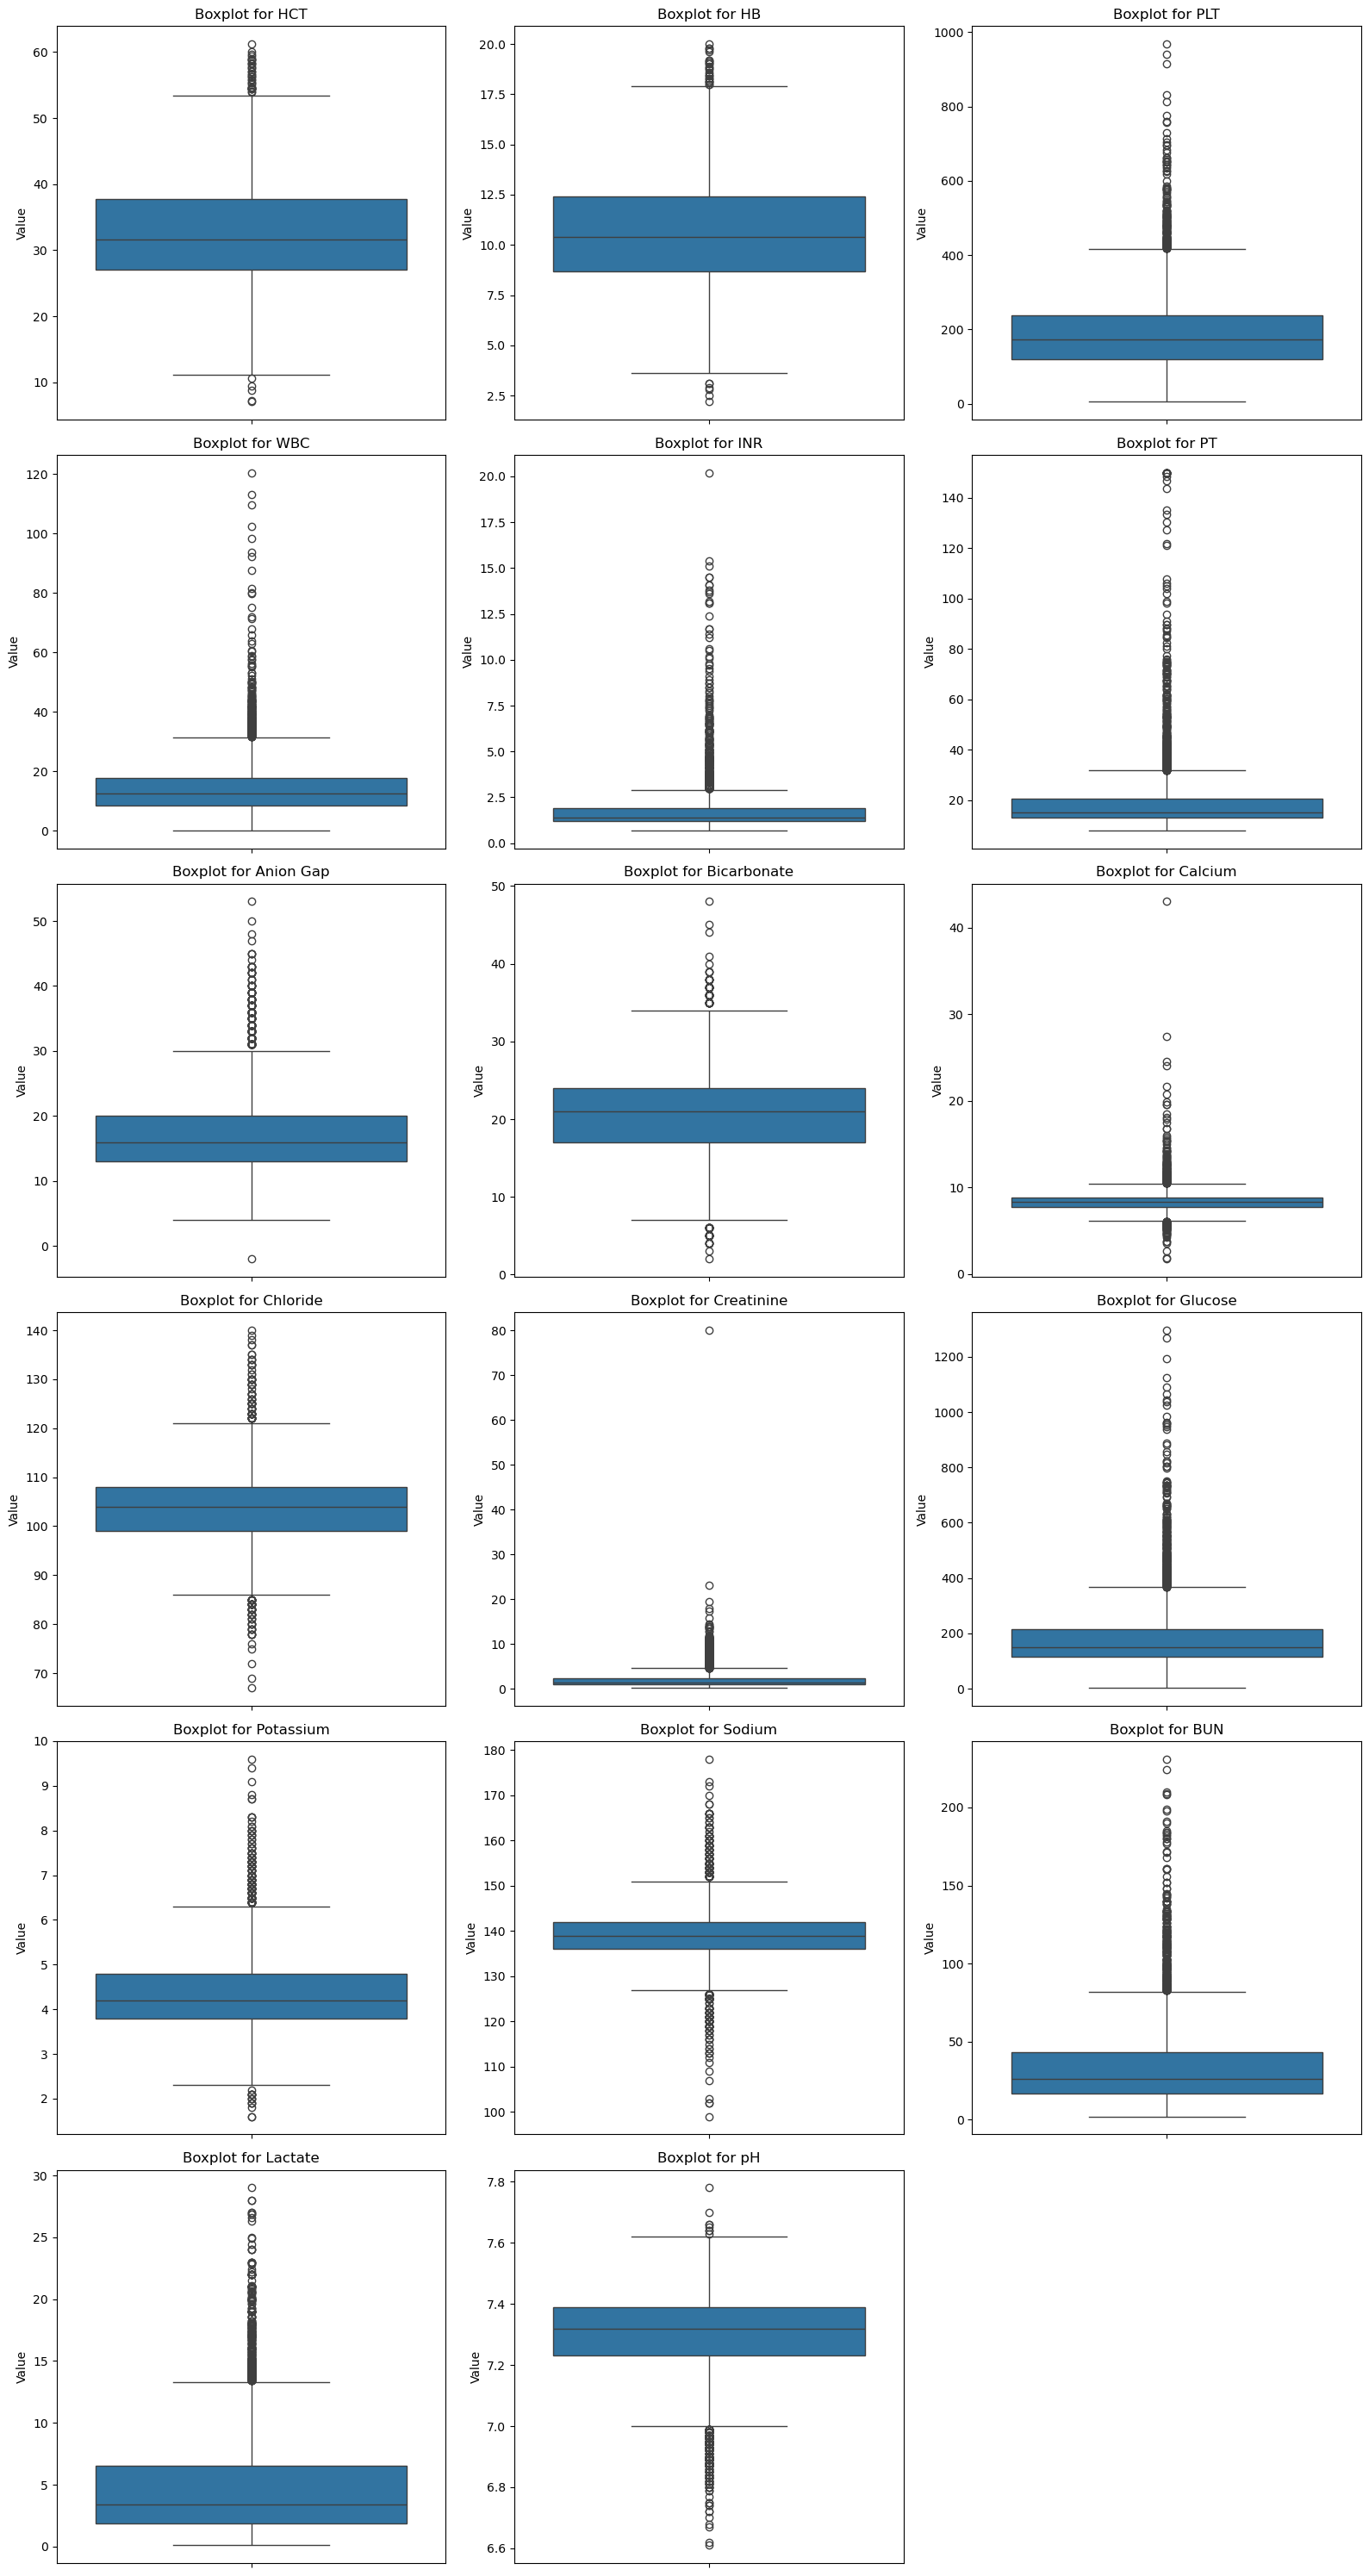

In [116]:
labs = df_filtered['lab_test'].unique()

# Set up the plot grid
num_labs = len(labs)
cols = 3
rows = (num_labs + cols - 1) // cols  # Ceiling division
plt.figure(figsize=(16, 5 * rows))

# Loop through each lab test
for i, lab in enumerate(labs, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(y='valuenum', data=df_filtered[df_filtered['lab_test'] == lab])
    plt.title(f'Boxplot for {lab}')
    plt.ylabel('Value')
    plt.tight_layout()

plt.show()

In [117]:
# Define acceptable ranges for labs
acceptable_lab_ranges = {
    'HCT': (15, 60),          # Hematocrit % [Typical range: 35-50%]
    'HB': (5, 20),            # Hemoglobin g/dL [Normal: ~12-17]
    'PLT': (20, 1000),        # Platelets (x10^3/µL) [Normal: 150-400]
    'WBC': (1, 50),           # WBC (x10^3/µL) [Normal: 4-11]
    'PT': (5, 50),            # Prothrombin Time seconds [Normal: 11-13 sec]
    'INR': (0.5, 5),          # International Normalized Ratio [Normal: 0.8-1.2]
    'Creatinine': (0.2, 15),  # Creatinine mg/dL [Normal: 0.6-1.3]
    'BUN': (1, 150),          # Blood Urea Nitrogen mg/dL [Normal: 7-20]
    'Glucose': (20, 600),     # Glucose mg/dL [Normal: 70-140]
    'Potassium': (2, 7),      # Potassium mEq/L [Normal: 3.5-5.0]
    'Sodium': (110, 170),     # Sodium mEq/L [Normal: 135-145]
    'Calcium': (5, 15),       # Calcium mg/dL [Normal: 8.5-10.5]
    'Chloride': (70, 130),    # Chloride mEq/L [Normal: 96-106]
    'Anion Gap': (0, 40),     # Anion gap mEq/L [Normal: 8-16]
    'Bicarbonate': (5, 50),   # Bicarbonate mEq/L [Normal: 22-28]
    'Lactate': (0.1, 20),     # Lactate mmol/L [Normal: 0.5-2.2]
    'pH': (6.8, 7.8)          # Arterial blood pH [Normal: 7.35-7.45]
}

# Function to filter outliers for lab tests
def filter_lab_outliers(row):
    lower, upper = acceptable_lab_ranges.get(row['lab_test'], (None, None))
    if lower is not None and pd.notnull(row['valuenum']):
        if row['valuenum'] < lower or row['valuenum'] > upper:
            return None
    return row['valuenum']

# Apply the filter
df_filtered['valuenum'] = df_filtered.apply(filter_lab_outliers, axis=1)

# Drop rows where valuenum became None (i.e., outliers)
df_cleaned = df_filtered.dropna(subset=['valuenum'])

In [118]:
df_cleaned.head()

,subject_id,hadm_id,itemid,valuenum,lab_test
8,10001884,26184834.0,51221,36.0,HCT
9,10001884,26184834.0,51222,11.4,HB
22,10001884,26184834.0,51265,171.0,PLT
30,10001884,26184834.0,51301,18.4,WBC
36,10001884,26184834.0,51237,1.4,INR


In [119]:
df_cleaned.groupby('lab_test')['valuenum'].describe()

,count,mean,std,min,25%,50%,75%,max
lab_test,,,,,,,,
Anion Gap,6451.0,17.044644,5.926333,4.0,13.00,16.00,20.00,40.00
BUN,6488.0,33.382090,23.335318,2.0,17.00,26.00,43.00,148.00
Bicarbonate,6540.0,20.349572,5.485261,5.0,17.00,21.00,24.00,48.00
Calcium,6071.0,8.290990,1.024331,5.0,7.70,8.30,8.80,15.00
Chloride,6656.0,103.880559,7.095337,72.0,99.00,104.00,108.00,130.00
Creatinine,6537.0,2.002952,1.765602,0.2,0.90,1.40,2.40,14.40
Glucose,6316.0,177.953927,91.954679,21.0,115.00,150.00,213.00,600.00
HB,5872.0,10.691945,2.521800,5.0,8.80,10.50,12.40,20.00
HCT,6305.0,32.560841,7.380307,15.0,27.00,31.70,37.70,59.60


In [120]:
# Count per lab test BEFORE cleaning (sort alphabetically by lab_test name)
before_counts = df_filtered['lab_test'].value_counts().sort_index()

# Count per lab test AFTER cleaning
after_counts = df_cleaned['lab_test'].value_counts().sort_index()

# Combine into a summary DataFrame
summary = pd.DataFrame({
    'Before_Cleaning': before_counts,
    'After_Cleaning': after_counts
})

# Calculate number and percentage of removed outliers
summary['Removed'] = summary['Before_Cleaning'] - summary['After_Cleaning']
summary['Percent_Removed'] = (summary['Removed'] / summary['Before_Cleaning'] * 100).round(2)

summary

,Before_Cleaning,After_Cleaning,Removed,Percent_Removed
lab_test,,,,
Anion Gap,6474,6451,23,0.36
BUN,6516,6488,28,0.43
Bicarbonate,6551,6540,11,0.17
Calcium,6108,6071,37,0.61
Chloride,6679,6656,23,0.34
Creatinine,6545,6537,8,0.12
Glucose,6396,6316,80,1.25
HB,5921,5872,49,0.83
HCT,6361,6305,56,0.88


In [121]:
# Save the cleaned data
df_cleaned.to_csv(f"{output__path}temp_labevents.csv", index=False)

In [122]:
# Start timer
start_time_part2 = time.time()

# Define paths
temp_filtered_path = f"{output__path}temp_labevents.csv"
ca_patients_filtered_path = f"{output__path}ca_patients_filtered.csv"
output_path = f"{output__path}labevents_summary.csv"

# Load entire filtered dataset using Pandas
filtered_pandas_df = pd.read_csv(temp_filtered_path)

# Convert to cuDF for GPU processing

# Group by and compute aggregates (all data in GPU memory)
final_labevents_df = filtered_pandas_df.groupby(['subject_id', 'hadm_id', 'itemid']).agg({
    'valuenum': ['mean', 'min', 'max']
}).reset_index()

# Flatten column names
final_labevents_df.columns = ['subject_id', 'hadm_id', 'itemid', 'average_value', 'min_value', 'max_value']

# Load CA patients data with additional columns (excluding 'intime', 'outtime')
ca_patients_additional = pd.read_csv(
    ca_patients_filtered_path,
    usecols=['subject_id', 'hadm_id', 'stay_id', 'icd_code', 
             'gender', 'anchor_age', 'anchor_year', 'anchor_year_group', 'dod', 'survival_status']
)

# Merge aggregated labtests with patient metadata
final_labevents_df = final_labevents_df.merge(
    ca_patients_additional,
    on=['subject_id', 'hadm_id'],
    how='left'  # Ensure all labtests rows are preserved
)

# Convert to Pandas and save to CSV
final_labevents_df.to_csv(output_path, index=False)

# Clean up temporary file
if os.path.exists(temp_filtered_path):
    os.remove(temp_filtered_path)

# End timer and report
end_time_part2 = time.time()
elapsed_time_part2 = (end_time_part2 - start_time_part2) / 60


print(f"✅ Processed {final_labevents_df.shape[0]} rows and saved to {output_path}")
print(f"⏳ Part 2 execution time: {elapsed_time_part2:.2f} minutes")

✅ Processed 36431 rows and saved to ../Outputs/labevents_summary.csv
⏳ Part 2 execution time: 0.00 minutes


In [123]:
final_labevents_df.head(2)

,subject_id,hadm_id,itemid,average_value,min_value,max_value,icd_code,stay_id,gender,anchor_age,anchor_year,anchor_year_group,dod,survival_status
0,10001884,26184834.0,50813,1.30,1.10,1.50,I469,37510196,F,68,2122,2008 - 2010,2131-01-20 05:15:00,1
1,10001884,26184834.0,50820,7.34,7.32,7.36,I469,37510196,F,68,2122,2008 - 2010,2131-01-20 05:15:00,1


In [124]:
# Check for exact duplicates considering 'subject_id', 'hadm_id', 'stay_id', and 'itemid'
duplicates_with_itemid = final_labevents_df[final_labevents_df.duplicated(subset=['subject_id', 'hadm_id', 'itemid'], keep=False)]

# Get the number of duplicate rows
num_duplicates = duplicates_with_itemid.shape[0]
print(f"Number of duplicate rows (with itemid): {num_duplicates}")

Number of duplicate rows (with itemid): 0


In [125]:
# 🔹 Step 0: Define lab test item IDs and their meaningful names
lab_itemids = {
    51221: 'Hematocrit',
    51222: 'Hemoglobin',
    51265: 'Platelet',
    51301: 'WBC',  # White Blood Cells
    51274: 'PT',   # Prothrombin Time
    51237: 'INR',  # International Normalized Ratio
    50912: 'Creatinine',
    51006: 'BUN',  # Urea Nitrogen (Blood Urea Nitrogen)
    50931: 'Glucose',
    50971: 'Potassium',
    50983: 'Sodium',
    50893: 'Calcium',
    50902: 'Chloride',
    50868: 'AnionGap',
    50882: 'Bicarbonate',
    50813: 'Lactate',
    50820: 'pH'  # Hydrogen Ion Concentration
}


# 🔹 Step 1: Load your lab events summary
lab_path = f"{output__path}labevents_summary.csv"
lab_df = pd.read_csv(lab_path)

# 🔹 Step 2: Filter to keep only lab tests we care about
lab_filtered = lab_df[lab_df['itemid'].isin(lab_itemids.keys())]

# 🔹 Step 3: Pivot to wide format: one row per patient/admission, one column per lab
lab_pivot = lab_filtered.pivot(index=['subject_id', 'hadm_id', 'stay_id'], 
                               columns='itemid', 
                               values='average_value').reset_index()

# 🔹 Step 4: Rename columns from itemid to lab names
lab_pivot = lab_pivot.rename(columns=lab_itemids)

# 🔹 Step 5: Merge with additional patient information
additional_columns = ['icd_code', 'gender', 'anchor_age', 'anchor_year', 'anchor_year_group', 'dod', 'survival_status']
patient_info = lab_df[['subject_id', 'hadm_id', 'stay_id'] + additional_columns].drop_duplicates()

final_lab_df = lab_pivot.merge(patient_info, on=['subject_id', 'hadm_id', 'stay_id'], how='left')

# 🔹 Step 6: Reorder columns nicely
desired_order = ['subject_id', 'hadm_id', 'stay_id'] + list(lab_itemids.values()) + additional_columns
final_lab_df = final_lab_df[desired_order]

# 🔹 Step 7: Save final lab summary
output_path = f"{output__path}labevents_final_summary.csv"
final_lab_df.to_csv(output_path, index=False)

# 🔹 Step 8: Print basic statistics
print(f"✅ Final lab dataframe saved to {output_path}.")

print(f"Total Number of Observations: {len(final_lab_df)}")
print(f"Total Number of Unique Patients: {final_lab_df['subject_id'].nunique()}")
print(f"Total Hospital Admissions Identified: {final_lab_df['hadm_id'].nunique()}")
print(f"Total ICU Admissions Identified: {final_lab_df['stay_id'].nunique()}")

✅ Final lab dataframe saved to ../Outputs/labevents_final_summary.csv.
Total Number of Observations: 2236
Total Number of Unique Patients: 2236
Total Hospital Admissions Identified: 2236
Total ICU Admissions Identified: 2236


In [126]:
ca_patients = pd.read_csv(ca_patients_path)
len(ca_patients)

2307

In [127]:
# Merge final_df into ca_patients using a left join
# Define join keys
join_keys = ['subject_id', 'hadm_id', 'stay_id']

# Get only columns in final_df that are NOT in ca_patients (excluding join keys)
final_df_extra_cols = [col for col in final_lab_df.columns 
                       if col not in ca_patients.columns or col in join_keys]

# Merge: preserve all info from ca_patients, and only add new info from final_df
final_df_expanded = ca_patients.merge(final_lab_df[final_df_extra_cols], on=join_keys, how='left')

print(len(final_df_expanded))
final_df_expanded.head()


2307


,subject_id,hadm_id,icd_code,stay_id,intime,outtime,los,gender,anchor_age,anchor_year,...,BUN,Glucose,Potassium,Sodium,Calcium,Chloride,AnionGap,Bicarbonate,Lactate,pH
0,10001884,26184834,I469,37510196,2131-01-11 04:20:05,2131-01-20 08:27:30,9.171817,F,68,2122,...,28.00,146.50,4.10,137.00,9.250,97.0,11.00,33.0,1.30,7.340
1,10009823,22096005,I469,31805686,2150-12-06 06:46:10,2150-12-06 20:33:52,0.574792,F,45,2150,...,23.00,149.00,4.90,144.00,7.900,116.0,14.00,13.0,3.40,7.190
2,10010471,29842315,I462,32119961,2155-12-02 20:33:00,2155-12-07 18:19:18,4.907153,F,89,2155,...,55.00,136.00,6.00,137.00,8.500,94.0,23.00,26.0,2.15,NaN
3,10013569,27993048,4275,38857852,2167-11-26 16:26:07,2167-12-05 16:53:53,9.019282,F,54,2165,...,79.00,330.00,4.80,131.00,9.100,87.0,19.00,30.0,NaN,7.350
4,10021454,29492087,I469,33300154,2125-03-17 02:41:26,2125-03-24 20:18:57,7.734387,M,88,2125,...,16.75,150.75,4.35,141.25,8.625,109.0,12.75,19.5,2.95,7.362


In [128]:
final_lab_df = final_df_expanded.copy()

In [129]:
# List of lab test columns to check
lab_columns = ['Hematocrit', 'Hemoglobin', 'Platelet', 'WBC', 'PT', 'INR', 
               'Creatinine', 'BUN', 'Glucose', 'Potassium', 'Sodium', 
               'Calcium', 'Chloride', 'AnionGap', 'Bicarbonate', 'Lactate', 'pH']

# Calculate number and percentage of missing values
missing_count = final_lab_df[lab_columns].isna().sum()
missing_percent = final_lab_df[lab_columns].isna().mean() * 100

# Combine into a summary DataFrame
missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_percent.round(2)
})

# Print the summary
print("🧪 Missing Values Summary (Lab Tests):")
print(missing_summary)

🧪 Missing Values Summary (Lab Tests):
             Missing Count  Missing %
Hematocrit             106       4.59
Hemoglobin             112       4.85
Platelet               117       5.07
WBC                    125       5.42
PT                     252      10.92
INR                    249      10.79
Creatinine             102       4.42
BUN                    107       4.64
Glucose                110       4.77
Potassium              104       4.51
Sodium                  97       4.20
Calcium                157       6.81
Chloride                99       4.29
AnionGap               102       4.42
Bicarbonate            101       4.38
Lactate                442      19.16
pH                     406      17.60


📁 Lab tests plot saved to: ../Outputs/plots/lab_test_distributions.png

Skewness of each lab test:
Hematocrit: 0.47
Hemoglobin: 0.44
Platelet: 1.49
WBC: 1.23
PT: 1.92
INR: 2.05
Creatinine: 2.67
BUN: 1.70
Glucose: 1.52
Potassium: 0.76
Sodium: 0.03
Calcium: 0.78
Chloride: -0.23
AnionGap: 1.19
Bicarbonate: -0.03
Lactate: 1.89
pH: -1.16


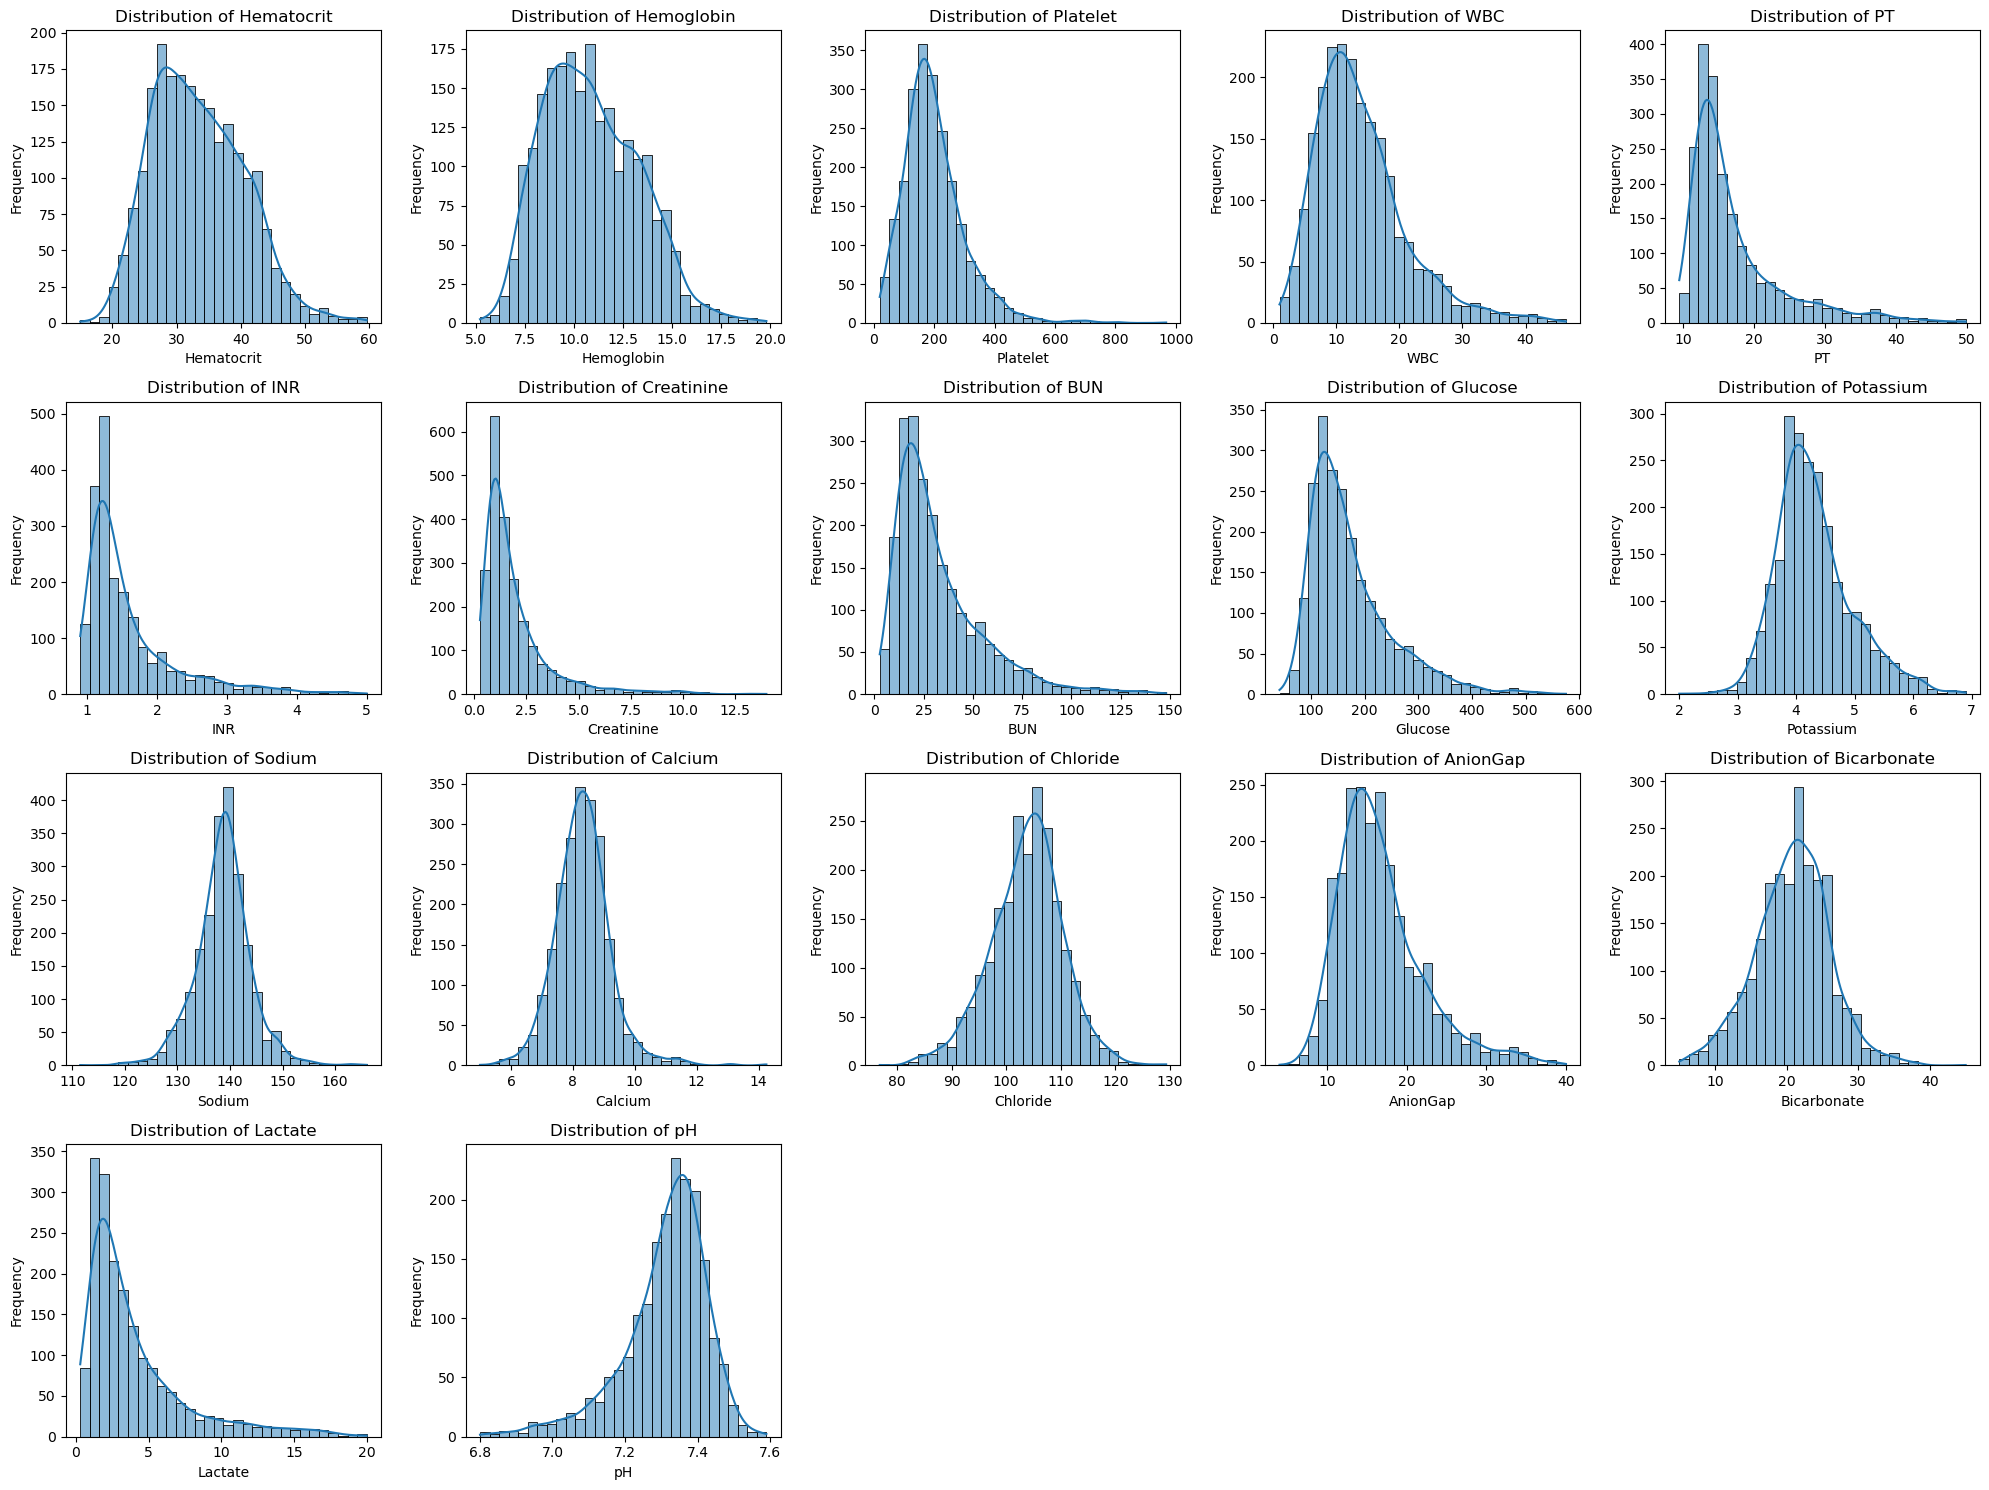

In [130]:
# List of lab test columns
lab_columns = ['Hematocrit', 'Hemoglobin', 'Platelet', 'WBC', 'PT', 'INR', 
               'Creatinine', 'BUN', 'Glucose', 'Potassium', 'Sodium', 
               'Calcium', 'Chloride', 'AnionGap', 'Bicarbonate', 'Lactate', 'pH']

# Set up the plot
plt.figure(figsize=(20, 15))

# Loop through each lab test and plot its distribution
for i, column in enumerate(lab_columns, 1):
    plt.subplot(4, 5, i)  # 4 rows x 5 columns
    sns.histplot(final_lab_df[column].dropna(), kde=True, bins=30)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')

plt.tight_layout()

# ✅ Save the plot
output_dir = f"{output__path}plots"
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, "lab_test_distributions.png")
plt.savefig(output_path, dpi=300)

# Optional: display it
# plt.show()

print(f"📁 Lab tests plot saved to: {output_path}")

# ✅ Also: calculate and print skewness for each lab test
print("\nSkewness of each lab test:")
for column in lab_columns:
    column_skewness = skew(final_lab_df[column].dropna())  # Drop missing values
    print(f"{column}: {column_skewness:.2f}")

In [131]:
"""
# List of lab variables for median imputation (excluding the ones for mean imputation)
median_impute_lab_vars = ['Hematocrit', 'Hemoglobin',
                          'Creatinine', 'BUN', 'Glucose', 'Potassium', 'AnionGap']

# Variables to impute using mean
mean_impute_lab_vars = ['Sodium', 'Chloride', 'Bicarbonate']

# Apply median imputation
for col in median_impute_lab_vars:
    final_lab_df[col] = final_lab_df[col].fillna(final_lab_df[col].median())

# Apply mean imputation
for col in mean_impute_lab_vars:
    final_lab_df[col] = final_lab_df[col].fillna(final_lab_df[col].mean())
"""
print('remove imputation!')

remove imputation!


In [132]:
# List of lab test columns to check
lab_columns = ['Hematocrit', 'Hemoglobin', 'Platelet', 'WBC', 'PT', 'INR', 
               'Creatinine', 'BUN', 'Glucose', 'Potassium', 'Sodium', 
               'Calcium', 'Chloride', 'AnionGap', 'Bicarbonate', 'Lactate', 'pH']

# Calculate number and percentage of missing values
missing_count = final_lab_df[lab_columns].isna().sum()
missing_percent = final_lab_df[lab_columns].isna().mean() * 100

# Combine into a summary DataFrame
missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_percent.round(2)
})

# Print the summary
print("🧪 Missing Values Summary (Lab Tests):")
print(missing_summary)

🧪 Missing Values Summary (Lab Tests):
             Missing Count  Missing %
Hematocrit             106       4.59
Hemoglobin             112       4.85
Platelet               117       5.07
WBC                    125       5.42
PT                     252      10.92
INR                    249      10.79
Creatinine             102       4.42
BUN                    107       4.64
Glucose                110       4.77
Potassium              104       4.51
Sodium                  97       4.20
Calcium                157       6.81
Chloride                99       4.29
AnionGap               102       4.42
Bicarbonate            101       4.38
Lactate                442      19.16
pH                     406      17.60


In [133]:
output_path_preiminary = f"{output__path}lab_vars_preliminary.csv"
final_lab_df.to_csv(output_path_preiminary, index=False)

In [134]:
"""
# Variables we want to impute and apply Rubin’s rule
impute_targets = ['Platelet', 'WBC', 'PT', 'INR', 'Calcium', 'Lactate', 'pH']

# Features to use for predicting missing values
# (We can customize this depending on your available variables)
impute_features = ['Hematocrit', 'Hemoglobin','Creatinine', 'BUN', 
                   'Glucose', 'Potassium', 'Sodium', 'Chloride', 'AnionGap', 'Bicarbonate'] + impute_targets

# Target variable (survival outcome)
target = 'survival_status'

# Store results
rubin_results = {}

# Loop through each variable you want to impute
for var in impute_targets:
    print(f"\n▶️ Processing variable: {var}")

    coefs = []
    ses = []
    imputed_versions = []

    # Create 5 imputed datasets
    for seed in range(5):
        imputer = IterativeImputer(random_state=seed, max_iter=10, sample_posterior=True)
        
        # Fit and transform
        imputed_data = imputer.fit_transform(final_lab_df[impute_features])
        imputed_df = pd.DataFrame(imputed_data, columns=impute_features)

        # Save the imputed version of the current variable
        imputed_versions.append(imputed_df[var].copy())
        
        # Prepare modeling data
        X = final_lab_df.copy()
        X[var] = imputed_df[var]  # only updating the current variable
        X = X.dropna(subset=impute_features + [target])  # Drop any remaining rows with missing predictors

        # Run logistic regression using statsmodels to get SE
        X_model = sm.add_constant(X[impute_features])  
        model = sm.Logit(X[target], X_model).fit(disp=0)


        coefs.append(model.params[var])
        ses.append(model.bse[var])

    # Apply Rubin’s Rule
    m = len(coefs)
    beta_mi = np.mean(coefs)
    V = np.mean(np.square(ses))
    B = np.var(coefs, ddof=1)
    T = V + (1 + 1/m) * B
    se_mi = np.sqrt(T)

    # Save results
    rubin_results[var] = {
        'pooled_coef': beta_mi,
        'pooled_se': se_mi,
        '95%_CI': (beta_mi - 1.96 * se_mi, beta_mi + 1.96 * se_mi),
        'imputed_variable': pd.concat(imputed_versions, axis=1).mean(axis=1),  # Final imputed values (average across datasets)
        'coefs': coefs,  # Save coefficients from all imputations
        'ses': ses       # Save standard errors from all imputations
    }

    print(f"✅ Pooled β ({var}): {beta_mi:.4f}")
    print(f"± SE: {se_mi:.4f}")
    print(f"95% CI: [{beta_mi - 1.96 * se_mi:.4f}, {beta_mi + 1.96 * se_mi:.4f}]")

# Update dataframe with the averaged imputed values
for var in impute_targets:
    final_lab_df[var] = rubin_results[var]['imputed_variable'].values
"""
print('remove imputation.')

remove imputation.


In [135]:
# List of lab test columns to check
lab_columns = ['Hematocrit', 'Hemoglobin', 'Platelet', 'WBC', 'PT', 'INR', 
               'Creatinine', 'BUN', 'Glucose', 'Potassium', 'Sodium', 
               'Calcium', 'Chloride', 'AnionGap', 'Bicarbonate', 'Lactate', 'pH']

# Calculate number and percentage of missing values
missing_count = final_lab_df[lab_columns].isna().sum()
missing_percent = final_lab_df[lab_columns].isna().mean() * 100

# Combine into a summary DataFrame
missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_percent.round(2)
})

# Print the summary
print("🧪 Missing Values Summary (Lab Tests):")
print(missing_summary)

🧪 Missing Values Summary (Lab Tests):
             Missing Count  Missing %
Hematocrit             106       4.59
Hemoglobin             112       4.85
Platelet               117       5.07
WBC                    125       5.42
PT                     252      10.92
INR                    249      10.79
Creatinine             102       4.42
BUN                    107       4.64
Glucose                110       4.77
Potassium              104       4.51
Sodium                  97       4.20
Calcium                157       6.81
Chloride                99       4.29
AnionGap               102       4.42
Bicarbonate            101       4.38
Lactate                442      19.16
pH                     406      17.60


In [136]:
"""
output_dir = f"{output__path}plots"
os.makedirs(output_dir, exist_ok=True)

# Loop through each variable in rubin_results to plot
for var_name, results in rubin_results.items():
    # Extract the imputed coefficients for each imputation
    imputed_coefs = np.array(results['coefs'])  # This will now store all coefficients
    ses = np.array(results['ses'])  # Standard errors for each imputation

    imputation_ids = np.arange(1, 6)  # Since there are 5 imputations

    # Calculate error bars: ±1.96 * SE (95% CI)
    error = 1.96 * ses

    # Plot the individual imputed coefficients with error bars
    plt.figure(figsize=(8, 5))
    plt.errorbar(imputation_ids, imputed_coefs, yerr=error, fmt='o', capsize=5, color='navy', label=f'Imputed β ({var_name})')
    
    # Plot the pooled coefficient as a dashed line
    pooled_coef = results['pooled_coef']
    plt.axhline(pooled_coef, color='orange', linestyle='--', label=f'Pooled β (mean): {pooled_coef:.3f}')
    plt.axhline(0, color='gray', linestyle=':')

    plt.title(f'Effect of {var_name} on In-Hospital Mortality\nAcross 5 Imputed Datasets')
    plt.xlabel('Imputation Number')
    plt.ylabel(f'Log-Odds Coefficient for {var_name}')
    plt.xticks(imputation_ids)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()

    # Save the figure for each variable
    output_path = os.path.join(output_dir, f"{var_name.lower()}_coefficients_across_imputations.png")
    plt.savefig(output_path, dpi=300)
    plt.show()

    print(f"📁 Plot saved to: {output_path}")
"""
print('remove imputation charts')

remove imputation charts


In [137]:
output_path = f"{output__path}lab_vars_finished.csv"
final_lab_df.to_csv(output_path, index=False)

In [138]:
final_lab_df.head()

,subject_id,hadm_id,icd_code,stay_id,intime,outtime,los,gender,anchor_age,anchor_year,...,BUN,Glucose,Potassium,Sodium,Calcium,Chloride,AnionGap,Bicarbonate,Lactate,pH
0,10001884,26184834,I469,37510196,2131-01-11 04:20:05,2131-01-20 08:27:30,9.171817,F,68,2122,...,28.00,146.50,4.10,137.00,9.250,97.0,11.00,33.0,1.30,7.340
1,10009823,22096005,I469,31805686,2150-12-06 06:46:10,2150-12-06 20:33:52,0.574792,F,45,2150,...,23.00,149.00,4.90,144.00,7.900,116.0,14.00,13.0,3.40,7.190
2,10010471,29842315,I462,32119961,2155-12-02 20:33:00,2155-12-07 18:19:18,4.907153,F,89,2155,...,55.00,136.00,6.00,137.00,8.500,94.0,23.00,26.0,2.15,NaN
3,10013569,27993048,4275,38857852,2167-11-26 16:26:07,2167-12-05 16:53:53,9.019282,F,54,2165,...,79.00,330.00,4.80,131.00,9.100,87.0,19.00,30.0,NaN,7.350
4,10021454,29492087,I469,33300154,2125-03-17 02:41:26,2125-03-24 20:18:57,7.734387,M,88,2125,...,16.75,150.75,4.35,141.25,8.625,109.0,12.75,19.5,2.95,7.362


## part 2 comorbidities

In [139]:
ca_patients_path = f"{output__path}ca_patients_filtered.csv"
ca_patients = pd.read_csv(ca_patients_path)
print(f"Loaded {ca_patients['subject_id'].nunique()} patients with {ca_patients['hadm_id'].nunique()} hospital admissions and {ca_patients['stay_id'].nunique()} icu admissions from filtered dataset.")
ca_patients.head()

Loaded 2307 patients with 2307 hospital admissions and 2307 icu admissions from filtered dataset.


,subject_id,hadm_id,icd_code,stay_id,intime,outtime,los,gender,anchor_age,anchor_year,anchor_year_group,dischtime,deathtime,dod,survival_status
0,10001884,26184834,I469,37510196,2131-01-11 04:20:05,2131-01-20 08:27:30,9.171817,F,68,2122,2008 - 2010,2131-01-20 05:15:00,2131-01-20 05:15:00,2131-01-20 05:15:00,1
1,10009823,22096005,I469,31805686,2150-12-06 06:46:10,2150-12-06 20:33:52,0.574792,F,45,2150,2020 - 2022,2150-12-06 14:22:00,2150-12-06 14:22:00,2150-12-06 14:22:00,1
2,10010471,29842315,I462,32119961,2155-12-02 20:33:00,2155-12-07 18:19:18,4.907153,F,89,2155,2014 - 2016,2155-12-07 15:30:00,2155-12-07 15:30:00,2155-12-07 15:30:00,1
3,10013569,27993048,4275,38857852,2167-11-26 16:26:07,2167-12-05 16:53:53,9.019282,F,54,2165,2008 - 2010,2167-12-25 14:53:00,NaN,NaN,0
4,10021454,29492087,I469,33300154,2125-03-17 02:41:26,2125-03-24 20:18:57,7.734387,M,88,2125,2020 - 2022,2125-03-24 16:43:00,2125-03-24 16:43:00,2125-03-24 16:43:00,1


In [140]:
# File paths
diagnoses_path = f"{input_path_hosp}diagnoses_icd.csv.gz"
ca_patients_path = f"{output__path}ca_patients_filtered.csv"

# Load data
diagnoses = pd.read_csv(diagnoses_path)
ca_patients = pd.read_csv(ca_patients_path)

print(f"Loaded {ca_patients['subject_id'].nunique()} patients from filtered dataset.")

# Define comorbidity ICD codes
comorbidities = {
    "hypertension": {
        "ICD9": [
            "4010", "4011", "4019", "40200", "40201", "40210", "40211", "40290", "40291",
            "40300", "40301", "40310", "40311", "40390", "40391", "40400", "40401", "40402", "40403",
            "40410", "40411", "40412", "40413", "40490", "40491", "40492", "40493",
            "40501", "40509", "40511", "40519", "40591", "40599"
        ],
        "ICD10": [
            "I10", "I11", "I110", "I119", "I12", "I120", "I129", "I13", "I130", "I131", "I1310", "I1311", "I132",
            "I15", "I150", "I151", "I152", "I158", "I159", "I16", "I160", "I161", "I169"
        ]
    },
    "congestive_heart_failure": {
        "ICD9": [
            "4280", "4281", "42820", "42821", "42822", "42823", "42830", "42831", "42832", "42833",
            "42840", "42841", "42842", "42843", "4289"
        ],
        "ICD10": [
            "I50", "I501", "I502", "I5020", "I5021", "I5022", "I5023",
            "I503", "I5030", "I5031", "I5032", "I5033",
            "I504", "I5040", "I5041", "I5042", "I5043",
            "I508", "I5081", "I50810", "I50811", "I50812", "I50813", "I50814",
            "I5082", "I5083", "I5084", "I5089", "I509"
        ]
    },
    "myocardial_infarction": {
        "ICD9": [
            "41000", "41001", "41002", "41010", "41011", "41012", "41020", "41021", "41022",
            "41030", "41031", "41032", "41040", "41041", "41042", "41050", "41051", "41052",
            "41060", "41061", "41062", "41070", "41071", "41072", "41080", "41081", "41082",
            "41090", "41091", "41092"
        ],
        "ICD10": [
            "I21", "I210", "I2101", "I2102", "I2109", "I211", "I2111", "I2119", "I212", "I2121",
            "I2129", "I213", "I214", "I219", "I21A", "I21A1", "I21A9"
        ]
    },
    "diabetes_mellitus": {
        "ICD9": [
            "25000", "25002", "25010", "25012", "25020", "25022", "25030", "25032", "25040", "25042",
            "25050", "25052", "25060", "25062", "25070", "25072", "25073", "25080", "25082", "25090", "25092"
        ],
        "ICD10": [
            "E11", "E110", "E1100", "E1101", "E111", "E1110", "E1111", "E112", "E1121", "E1122", "E1129",
            "E113", "E1131", "E11311", "E11319", "E1132", "E11321", "E113211", "E113212", "E113213", "E113219",
            "E11329", "E113291", "E113292", "E113293", "E113299", "E1133", "E11331", "E113311", "E113312",
            "E113313", "E113319", "E11339", "E113391", "E113392", "E113393", "E113399", "E1134", "E11341",
            "E113411", "E113412", "E113413", "E113419", "E11349", "E113491", "E113492", "E113493", "E113499",
            "E1135", "E11351", "E113511", "E113512", "E113513", "E113519", "E11352", "E113521", "E113522",
            "E113523", "E113529", "E11353", "E113531", "E113532", "E113533", "E113539", "E11354", "E113541",
            "E113542", "E113543", "E113549", "E11355", "E113551", "E113552", "E113553", "E113559", "E11359",
            "E113591", "E113592", "E113593", "E113599", "E1136", "E1137", "E1137X1", "E1137X2", "E1137X3",
            "E1137X9", "E1139", "E114", "E1140", "E1141", "E1142", "E1143", "E1144", "E1149", "E115",
            "E1151", "E1152", "E1159", "E116", "E1161", "E11610", "E11618", "E1162", "E11620", "E11621",
            "E11622", "E11628", "E1163", "E11630", "E11638", "E1164", "E11641", "E11649", "E1165", "E1169",
            "E118", "E119"
        ]
    },
    "copd": {
        "ICD9": [
            "490", "4910", "4911", "49120", "49121", "49122", "4918", "4919", "4920", "4928",
            "49300", "49301", "49302", "49310", "49311", "49312", "49320", "49321", "49322",
            "49381", "49382", "49390", "49391", "49392", "4940", "4941", "4950", "4951", "4952",
            "4953", "4954", "4955", "4956", "4957", "4958", "4959", "496"
        ],
        "ICD10": [
            "J40", "J41", "J410", "J411", "J418", "J42", "J43", "J430", "J431", "J432", "J438", "J439",
            "J44", "J440", "J441", "J449", "J45", "J452", "J4520", "J4521", "J4522", "J453", "J4530",
            "J4531", "J4532", "J454", "J4540", "J4541", "J4542", "J455", "J4550", "J4551", "J4552",
            "J459", "J4590", "J45901", "J45902", "J45909", "J4599", "J45990", "J45991", "J45998",
            "J47", "J470", "J471", "J479", "J67", "J670", "J671", "J672", "J673", "J674", "J675",
            "J676", "J677", "J678", "J679"
        ]
    }
}

# Filter diagnoses for relevant patients
diagnoses["icd_code"] = diagnoses["icd_code"].astype(str).str.upper().str.replace('.', '', regex=False)
diagnoses["icd_version"] = diagnoses["icd_version"].astype(int)
filtered_diagnoses = diagnoses[diagnoses["subject_id"].isin(ca_patients["subject_id"])]

# Add binary columns for comorbidities
for comorb in comorbidities:
    ca_patients[comorb] = 0
    matched_subjects = set()

    icd9_codes = comorbidities[comorb]["ICD9"]
    icd10_codes = comorbidities[comorb]["ICD10"]

    # Match ICD-9 codes
    icd9_match = filtered_diagnoses[
        (filtered_diagnoses["icd_version"] == 9) &
        (filtered_diagnoses["icd_code"].isin(icd9_codes))
    ]["hadm_id"]
    matched_subjects.update(icd9_match)

    # Match ICD-10 codes
    icd10_match = filtered_diagnoses[
        (filtered_diagnoses["icd_version"] == 10) &
        (filtered_diagnoses["icd_code"].isin(icd10_codes))
    ]["hadm_id"]
    matched_subjects.update(icd10_match)

    ca_patients[comorb] = ca_patients["hadm_id"].isin(matched_subjects).astype(int)

# Preview
ca_patients[["subject_id", "hadm_id", "hypertension", "congestive_heart_failure", "myocardial_infarction", "diabetes_mellitus", "copd"]].head()

Loaded 2307 patients from filtered dataset.


,subject_id,hadm_id,hypertension,congestive_heart_failure,myocardial_infarction,diabetes_mellitus,copd
0,10001884,26184834,1,0,0,0,1
1,10009823,22096005,1,0,0,0,0
2,10010471,29842315,1,1,1,0,1
3,10013569,27993048,1,1,0,0,0
4,10021454,29492087,1,0,0,0,0


In [141]:
print(len(ca_patients))
ca_patients.head(2)

2307


,subject_id,hadm_id,icd_code,stay_id,intime,outtime,los,gender,anchor_age,anchor_year,anchor_year_group,dischtime,deathtime,dod,survival_status,hypertension,congestive_heart_failure,myocardial_infarction,diabetes_mellitus,copd
0,10001884,26184834,I469,37510196,2131-01-11 04:20:05,2131-01-20 08:27:30,9.171817,F,68,2122,2008 - 2010,2131-01-20 05:15:00,2131-01-20 05:15:00,2131-01-20 05:15:00,1,1,0,0,0,1
1,10009823,22096005,I469,31805686,2150-12-06 06:46:10,2150-12-06 20:33:52,0.574792,F,45,2150,2020 - 2022,2150-12-06 14:22:00,2150-12-06 14:22:00,2150-12-06 14:22:00,1,1,0,0,0,0


In [142]:
output_path = f"{output__path}comorbidities_finished.csv"
ca_patients.to_csv(output_path, index=False)

## part 2 marking system

In [143]:
# Load the full dataset
df = pd.read_csv(f"{output__path}temp_filtered.csv")

# Define the item IDs and their score types
sofa_gcs_items = {
    #227428: 'SOFA', there is no SOFA score in the filtered dataset.
    220739: 'GCS_Eye',
    223900: 'GCS_Verbal',
    223901: 'GCS_Motor'
    #The variables below will be needed if we calculate SOFA score, however due to high number of missingness I decided not to do it.
    # 220224: 'resp_PaO2',
    # 223835: 'resp_FiO2',
    # 227457: 'coag_platelets',
    # 225690: 'liver_bilirubin',
    # 220181: 'cardio_map',
    # 220615: 'renal_creatinine'
}

# Extract only rows related to SOFA and GCS
df_scores = df[df['itemid'].isin(sofa_gcs_items.keys())].copy()
df_scores['score_type'] = df_scores['itemid'].map(sofa_gcs_items)
df_scores.groupby("score_type")["valuenum"].describe()

,count,mean,std,min,25%,50%,75%,max
score_type,,,,,,,,
GCS_Eye,13592.0,2.358888,1.324296,1.0,1.0,2.0,4.0,4.0
GCS_Motor,13516.0,3.736239,2.254091,1.0,1.0,5.0,6.0,6.0
GCS_Verbal,13562.0,2.109128,1.731657,1.0,1.0,1.0,4.0,5.0


In [144]:
pivot_scores = df_scores.pivot_table(
    index=['subject_id', 'hadm_id', 'stay_id'],
    columns='score_type',
    values='valuenum',
    aggfunc='mean' # change it if we will consider min or max values
).reset_index()

print(pivot_scores.shape)
pivot_scores.head()

(2254, 6)


score_type,subject_id,hadm_id,stay_id,GCS_Eye,GCS_Motor,GCS_Verbal
0,10001884,26184834,37510196,2.625,4.0,1.0
1,10009823,22096005,31805686,1.000,1.0,1.0
2,10010471,29842315,32119961,4.000,6.0,5.0
3,10013569,27993048,38857852,4.000,6.0,5.0
4,10021454,29492087,33300154,2.500,1.0,1.0


In [145]:
# Get full patient list
all_patients = df[['subject_id', 'hadm_id', 'stay_id']].drop_duplicates()

# Merge to keep all patients
df_merged = pd.merge(all_patients, pivot_scores, on=['subject_id', 'hadm_id', 'stay_id'], how='left')
print(df_merged.shape)
df_merged.head()

(2307, 6)


,subject_id,hadm_id,stay_id,GCS_Eye,GCS_Motor,GCS_Verbal
0,10001884,26184834,37510196,2.625,4.0,1.0
1,10009823,22096005,31805686,1.000,1.0,1.0
2,10010471,29842315,32119961,4.000,6.0,5.0
3,10013569,27993048,38857852,4.000,6.0,5.0
4,10021454,29492087,33300154,2.500,1.0,1.0


In [146]:
gcs_columns = ['GCS_Eye', 'GCS_Motor', 'GCS_Verbal']

# Calculate missing value percentages
missing_percent = df_merged[gcs_columns].isna().mean() * 100

print("Percentage of missing values per column:")
print(missing_percent.round(2).to_string())

Percentage of missing values per column:
GCS_Eye       2.30
GCS_Motor     2.34
GCS_Verbal    2.30


📁 Plot saved to: ../Outputs/plots/gcs_distributions.png

Skewness of each GCS component:
GCS_Eye: 0.10
GCS_Verbal: 0.80
GCS_Motor: -0.21


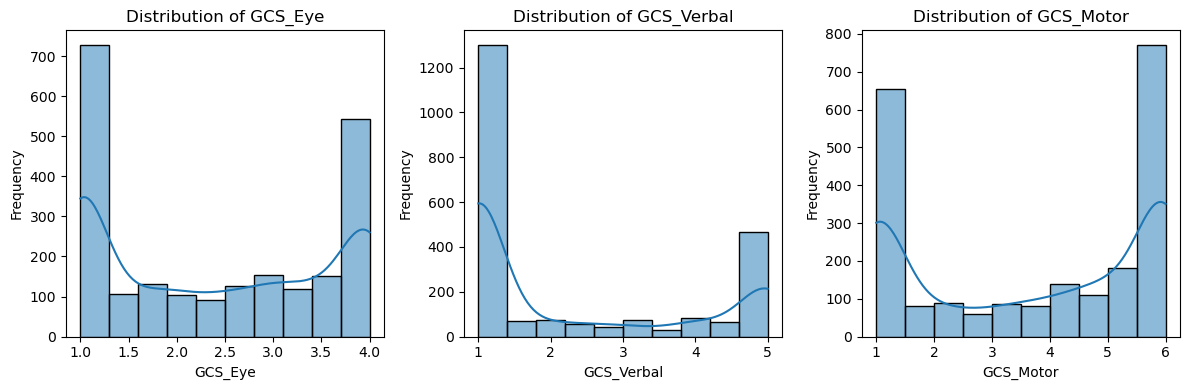

In [147]:
# List of GCS columns to check
gcs_columns = ['GCS_Eye', 'GCS_Verbal', 'GCS_Motor']

# Set up the plot
plt.figure(figsize=(12, 4))

# Loop through each GCS component and plot its distribution
for i, column in enumerate(gcs_columns, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df_merged[column].dropna(), kde=True, bins=10)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')

plt.tight_layout()

# Save the plot
output_dir = f"{output__path}plots"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "gcs_distributions.png")
plt.savefig(output_path, dpi=300)

print(f"📁 Plot saved to: {output_path}")

# Check skewness for each GCS component
print("\nSkewness of each GCS component:")
for column in gcs_columns:
    column_skewness = skew(df_merged[column].dropna())
    print(f"{column}: {column_skewness:.2f}")

In [148]:
"""
df_merged['GCS_Eye'] = df_merged['GCS_Eye'].fillna(df_merged['GCS_Eye'].mean())
df_merged['GCS_Motor'] = df_merged['GCS_Motor'].fillna(df_merged['GCS_Motor'].mean())
df_merged['GCS_Verbal'] = df_merged['GCS_Verbal'].fillna(df_merged['GCS_Verbal'].median())
"""
print('remove imputation!')

remove imputation!


In [149]:
df_merged['GCS_Total'] = df_merged['GCS_Eye'] + df_merged['GCS_Motor'] + df_merged['GCS_Verbal']
print(df_merged.shape)
df_merged.head()

(2307, 7)


,subject_id,hadm_id,stay_id,GCS_Eye,GCS_Motor,GCS_Verbal,GCS_Total
0,10001884,26184834,37510196,2.625,4.0,1.0,7.625
1,10009823,22096005,31805686,1.000,1.0,1.0,3.000
2,10010471,29842315,32119961,4.000,6.0,5.0,15.000
3,10013569,27993048,38857852,4.000,6.0,5.0,15.000
4,10021454,29492087,33300154,2.500,1.0,1.0,4.500


In [150]:
output_path = f"{output__path}marking_system_finished.csv"
df_merged.to_csv(output_path, index=False)